In [1]:
pip install kneed

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn kneed xgboost streamlit

In [3]:
# Importação de Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from kneed import KneeLocator
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [4]:
# from google.colab import drive
# drive.mount('/content/drive')
# Importação do dataset
df = pd.read_csv('data/crop_yield.csv')
df.head(5)

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [5]:
features = ['Soil_Type_Clay',
            'Soil_Type_Loam', 'Soil_Type_Peaty', 'Soil_Type_Sandy',
            'Soil_Type_Silt', 'Crop_Cotton', 'Crop_Maize', 'Crop_Rice', 'Crop_Soybean', 'Crop_Wheat', 'Rainfall_mm', 'Temperature_Celsius',
            'Fertilizer_Used', 'Irrigation_Used', 'Days_to_Harvest', 'Weather_Condition_Rainy', 'Weather_Condition_Sunny']

In [6]:
scaler = MinMaxScaler()

df['Days_to_Harvest'] = scaler.fit_transform(df[['Days_to_Harvest']])

In [7]:
scaler = StandardScaler()

df['Yield_tons_per_hectare'] = scaler.fit_transform(df[['Yield_tons_per_hectare']])
df['Temperature_Celsius'] = scaler.fit_transform(df[['Temperature_Celsius']])
df['Rainfall_mm'] = scaler.fit_transform(df[['Rainfall_mm']])

In [8]:
# Uplicando o One-Hot Encoding  na coluna Crop
df_encoded = pd.get_dummies(df, columns=['Crop'], drop_first=True)
df_Crop = df_encoded.copy()

In [9]:
df_Region = pd.get_dummies(df_Crop, columns=['Region'], drop_first=True)
df_Type = pd.get_dummies(df_Region, columns=['Soil_Type'], drop_first=True)
df_Encoding = pd.get_dummies(df_Type, columns=['Weather_Condition'], drop_first=True)

In [10]:
df_Encoding.head()

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare,Crop_Cotton,Crop_Maize,Crop_Rice,Crop_Soybean,...,Region_North,Region_South,Region_West,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt,Weather_Condition_Rainy,Weather_Condition_Sunny
0,1.335747,0.023821,False,True,0.696629,1.123645,True,False,False,False,...,False,False,True,False,False,False,True,False,False,False
1,1.703634,-1.312747,True,True,0.898876,2.285709,False,False,True,False,...,False,True,False,True,False,False,False,False,True,False
2,-1.546977,0.317020,False,False,0.516854,-2.075968,False,False,False,False,...,True,False,False,False,True,False,False,False,False,True
3,1.681287,-1.504137,False,True,0.966292,1.101103,False,False,False,True,...,True,False,False,False,False,False,True,False,True,False
4,0.694233,0.569997,True,True,0.561798,1.531783,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False


In [11]:
df_Encoding.columns

Index(['Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used',
       'Irrigation_Used', 'Days_to_Harvest', 'Yield_tons_per_hectare',
       'Crop_Cotton', 'Crop_Maize', 'Crop_Rice', 'Crop_Soybean', 'Crop_Wheat',
       'Region_North', 'Region_South', 'Region_West', 'Soil_Type_Clay',
       'Soil_Type_Loam', 'Soil_Type_Peaty', 'Soil_Type_Sandy',
       'Soil_Type_Silt', 'Weather_Condition_Rainy', 'Weather_Condition_Sunny'],
      dtype='object')

In [12]:
X = df_Encoding[features]
# X = df_Encoding[features]
X.head()

,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt,Crop_Cotton,Crop_Maize,Crop_Rice,Crop_Soybean,Crop_Wheat,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Weather_Condition_Rainy,Weather_Condition_Sunny
0,False,False,False,True,False,True,False,False,False,False,1.335747,0.023821,False,True,0.696629,False,False
1,True,False,False,False,False,False,False,True,False,False,1.703634,-1.312747,True,True,0.898876,True,False
2,False,True,False,False,False,False,False,False,False,False,-1.546977,0.317020,False,False,0.516854,False,True
3,False,False,False,True,False,False,False,False,True,False,1.681287,-1.504137,False,True,0.966292,True,False
4,False,False,False,False,True,False,False,False,False,True,0.694233,0.569997,True,True,0.561798,False,False


In [13]:
#  Separar colunas categóricas e numéricas
cat_cols = ['Soil_Type_Clay', 'Soil_Type_Loam', 'Soil_Type_Peaty', 'Soil_Type_Sandy', 'Soil_Type_Silt', 'Crop_Cotton', 'Crop_Maize', 'Crop_Rice', 'Crop_Soybean', 'Crop_Wheat', 'Weather_Condition_Rainy', 'Weather_Condition_Sunny', 'Fertilizer_Used', 'Irrigation_Used']
num_cols = ['Rainfall_mm', 'Temperature_Celsius', 'Days_to_Harvest']


#  One-hot encode das variáveis categóricas
# encoder = OneHotEncoder(drop='first', sparse=False)
encoder = OneHotEncoder(drop='first', sparse_output=False)
X_cat = encoder.fit_transform(X[cat_cols])

#  Normalizar variáveis numéricas
scaler = StandardScaler()
X_num = scaler.fit_transform(X[num_cols])

#  Concatenar tudo
import numpy as np
X_final = np.concatenate([X_cat, X_num], axis=1)

#  Rodar KMeans com 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)
df_Encoding['Cluster'] = kmeans.fit_predict(X_final)


In [14]:
df_Encoding.Cluster.unique()

array([3, 0, 1, 2, 4], dtype=int32)

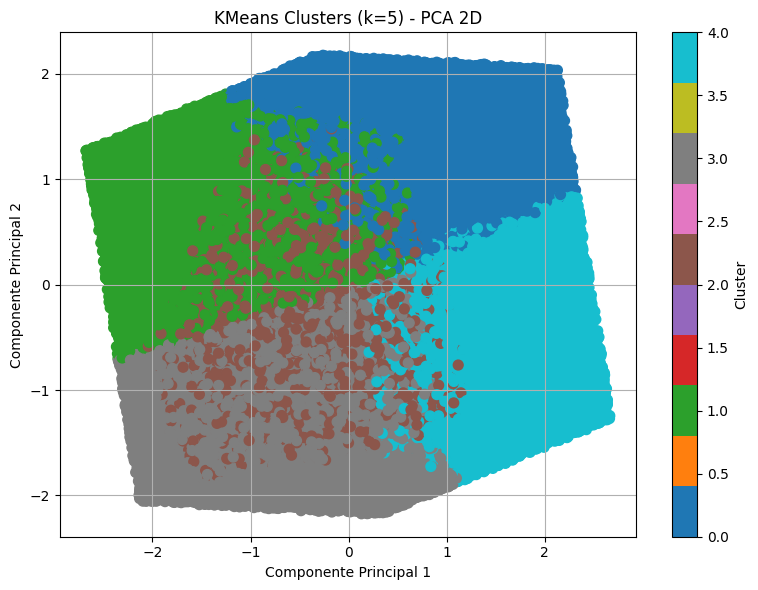

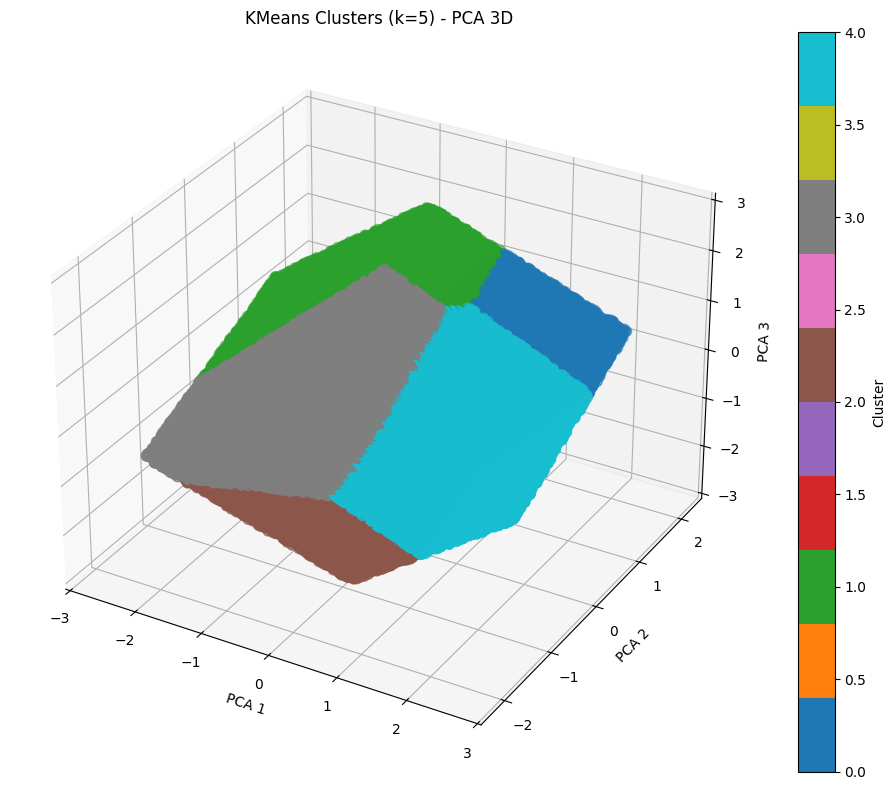

In [15]:
# PCA 2D
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_final)

# PCA 3D
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_final)

# 2D Plot
plt.figure(figsize=(8, 6))
scatter_2d = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=df_Encoding['Cluster'], cmap='tab10', s=50)
plt.title('KMeans Clusters (k=5) - PCA 2D')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(scatter_2d, label='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

# 3D Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter_3d = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                        c=df_Encoding['Cluster'], cmap='tab10', s=50)
ax.set_title('KMeans Clusters (k=5) - PCA 3D')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
fig.colorbar(scatter_3d, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()


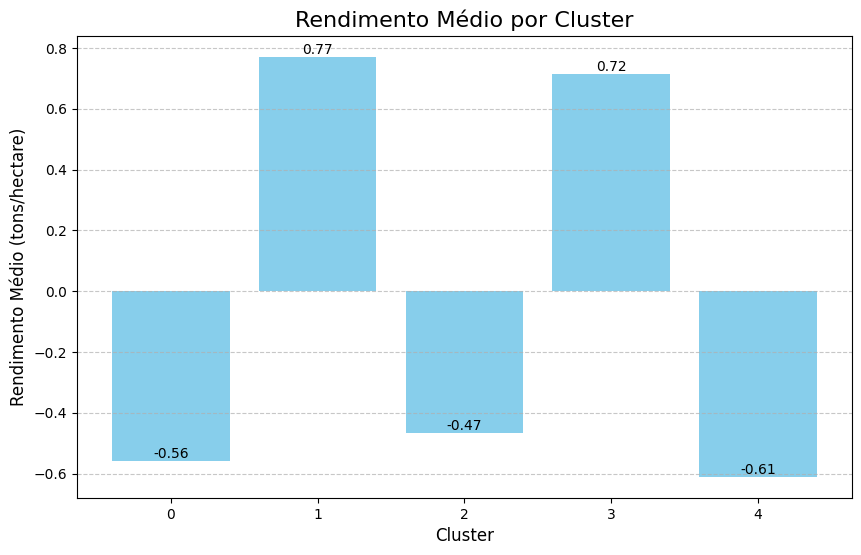

In [16]:
# Supondo que seu DataFrame seja df_Encoding
# Se você ainda não carregou os dados, faça isso primeiro.
# Exemplo: df_Encoding = pd.read_csv('seu_arquivo.csv')

# 1. Calcular a média de 'Yield_tons_per_hectare' para cada cluster
# Isso cria uma nova série com os clusters como índice e o rendimento médio como valores
df_grouped = df_Encoding.groupby('Cluster')['Yield_tons_per_hectare'].mean()

# 2. Criar o gráfico de barras
plt.figure(figsize=(10, 6))  # Opcional: define o tamanho do gráfico para melhor visualização
plt.bar(df_grouped.index, df_grouped.values, color='skyblue')

# 3. Adicionar títulos e rótulos
plt.title('Rendimento Médio por Cluster', fontsize=16)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Rendimento Médio (tons/hectare)', fontsize=12)

# 4. Adicionar rótulos para os valores das barras (opcional)
for index, value in enumerate(df_grouped.values):
    plt.text(index, value, f'{value:.2f}', ha='center', va='bottom')

# 5. Adicionar grade para facilitar a leitura
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 6. Salvar o gráfico em um arquivo (opcional)
plt.savefig('grafico_rendimento_por_cluster.png')

# 7. Exibir o gráfico (opcional)
plt.show()

In [17]:
df_Encoding.head()

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare,Crop_Cotton,Crop_Maize,Crop_Rice,Crop_Soybean,...,Region_South,Region_West,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt,Weather_Condition_Rainy,Weather_Condition_Sunny,Cluster
0,1.335747,0.023821,False,True,0.696629,1.123645,True,False,False,False,...,False,True,False,False,False,True,False,False,False,3
1,1.703634,-1.312747,True,True,0.898876,2.285709,False,False,True,False,...,True,False,True,False,False,False,False,True,False,3
2,-1.546977,0.317020,False,False,0.516854,-2.075968,False,False,False,False,...,False,False,False,True,False,False,False,False,True,0
3,1.681287,-1.504137,False,True,0.966292,1.101103,False,False,False,True,...,False,False,False,False,False,True,False,True,False,3
4,0.694233,0.569997,True,True,0.561798,1.531783,False,False,False,False,...,True,False,False,False,False,False,True,False,False,1


Melhor número de clusters estimado (k): 4


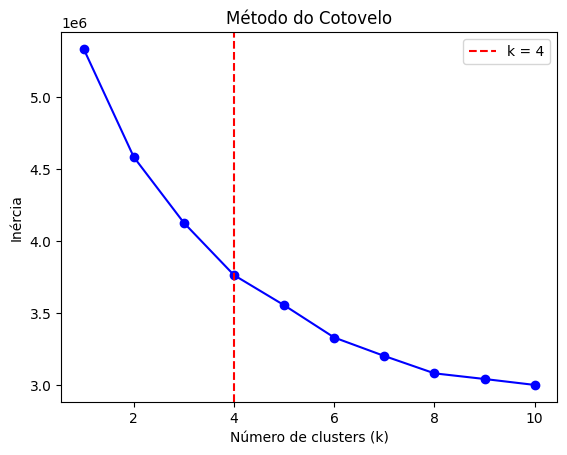

In [18]:
# 2. Separar colunas categóricas e numéricas
cat_cols = ['Soil_Type_Clay', 'Soil_Type_Loam', 'Soil_Type_Peaty', 'Soil_Type_Sandy', 'Soil_Type_Silt', 'Crop_Cotton', 'Crop_Maize', 'Crop_Rice', 'Crop_Soybean', 'Crop_Wheat', 'Weather_Condition_Rainy', 'Weather_Condition_Sunny', 'Fertilizer_Used', 'Irrigation_Used']
num_cols = ['Rainfall_mm', 'Temperature_Celsius', 'Days_to_Harvest']

# 3. One-hot encode das variáveis categóricas
encoder = OneHotEncoder(drop='first', sparse_output=False)
X_cat = encoder.fit_transform(X[cat_cols])

# 4. Normalizar variáveis numéricas
scaler = StandardScaler()
X_num = scaler.fit_transform(X[num_cols])

# 5. Concatenar tudo
X_final = np.concatenate([X_cat, X_num], axis=1)

# 6. Encontrar o melhor valor de k usando a regra do cotovelo
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_final)
    inertias.append(kmeans.inertia_)

# 7. Encontrar o "cotovelo"
kl = KneeLocator(k_range, inertias, curve="convex", direction="decreasing")
best_k = kl.elbow

print(f"Melhor número de clusters estimado (k): {best_k}")

# 8. Plotar o gráfico do cotovelo (opcional)
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')
plt.axvline(best_k, color='r', linestyle='--', label=f'k = {best_k}')
plt.legend()
plt.show()

# 9. Rodar o KMeans com o melhor k
kmeans = KMeans(n_clusters=best_k, random_state=42)
df_Encoding['Cluster'] = kmeans.fit_predict(X_final)


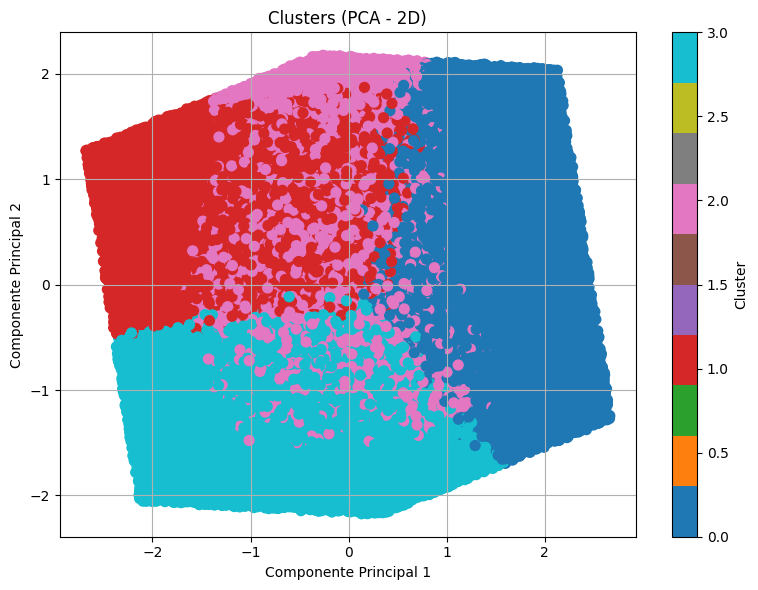

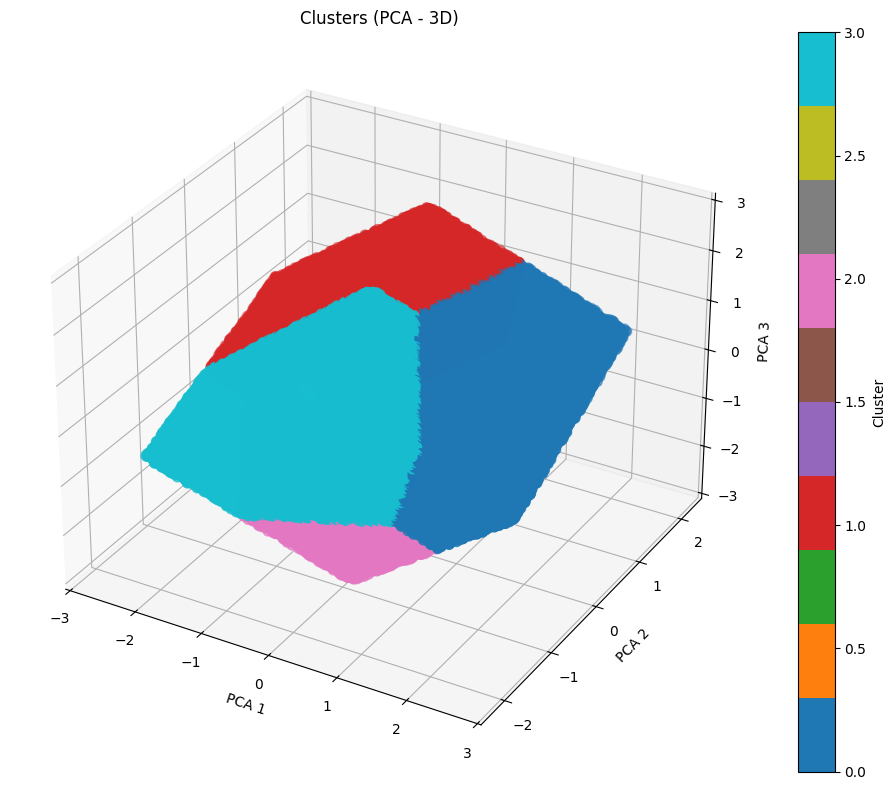

In [19]:
# Aplicar PCA para redução de dimensionalidade
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_final)

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_final)

# Adicionando colunas PCA ao DataFrame (opcional)
df_Encoding['PCA1'] = X_pca_2d[:, 0]
df_Encoding['PCA2'] = X_pca_2d[:, 1]

# Plot 2D
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=df_Encoding['Cluster'], cmap='tab10', s=50)
plt.title('Clusters (PCA - 2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter_3d = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                        c=df_Encoding['Cluster'], cmap='tab10', s=50)
ax.set_title('Clusters (PCA - 3D)')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
fig.colorbar(scatter_3d, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()


In [20]:
df_Encoding.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 24 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   Rainfall_mm              1000000 non-null  float64
 1   Temperature_Celsius      1000000 non-null  float64
 2   Fertilizer_Used          1000000 non-null  bool   
 3   Irrigation_Used          1000000 non-null  bool   
 4   Days_to_Harvest          1000000 non-null  float64
 5   Yield_tons_per_hectare   1000000 non-null  float64
 6   Crop_Cotton              1000000 non-null  bool   
 7   Crop_Maize               1000000 non-null  bool   
 8   Crop_Rice                1000000 non-null  bool   
 9   Crop_Soybean             1000000 non-null  bool   
 10  Crop_Wheat               1000000 non-null  bool   
 11  Region_North             1000000 non-null  bool   
 12  Region_South             1000000 non-null  bool   
 13  Region_West              1000000 non-null  

In [21]:
df_Encoding.describe()

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare,Cluster,PCA1,PCA2
count,1.000000e+06,1.000000e+06,1000000.000000,1.000000e+06,1000000.000000,1.000000e+06,1.000000e+06
mean,-6.700702e-16,-8.367351e-17,0.499944,7.428298e-16,1.496940,-2.632646e-15,1.374474e-16
std,1.000001e+00,1.000001e+00,0.291611,1.000001e+00,1.118562,1.001370e+00,1.000034e+00
min,-1.731687e+00,-1.731840e+00,0.000000,-3.416941e+00,0.000000,-2.678327e+00,-2.174944e+00
25%,-8.662297e-01,-8.656427e-01,0.247191,-7.260731e-01,0.000000,-7.184720e-01,-8.351355e-01
50%,5.470826e-04,3.324143e-04,0.494382,1.376680e-03,1.000000,-4.529743e-04,3.201534e-05
75%,8.649436e-01,8.653434e-01,0.752809,7.248310e-01,2.000000,7.190393e-01,8.339535e-01
max,1.731823e+00,1.730469e+00,1.000000,3.132140e+00,3.000000,2.662083e+00,2.177735e+00


In [22]:
cluster0 = df_Encoding[df_Encoding['Cluster'] == 0]
cluster1 = df_Encoding[df_Encoding['Cluster'] == 1]
cluster2 = df_Encoding[df_Encoding['Cluster'] == 2]
cluster3 = df_Encoding[df_Encoding['Cluster'] == 3]

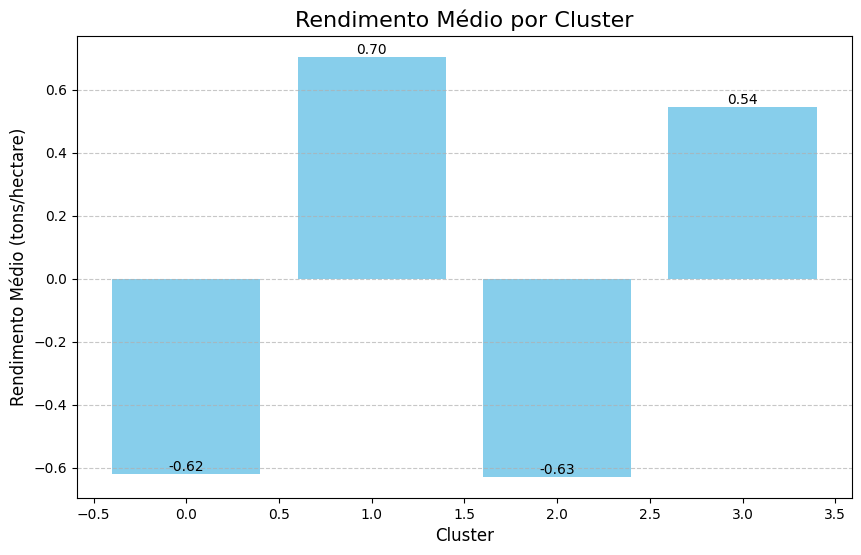

In [23]:
# Supondo que seu DataFrame seja df_Encoding
# Se você ainda não carregou os dados, faça isso primeiro.
# Exemplo: df_Encoding = pd.read_csv('seu_arquivo.csv')

# 1. Calcular a média de 'Yield_tons_per_hectare' para cada cluster
# Isso cria uma nova série com os clusters como índice e o rendimento médio como valores
df_grouped = df_Encoding.groupby('Cluster')['Yield_tons_per_hectare'].mean()

# 2. Criar o gráfico de barras
plt.figure(figsize=(10, 6))  # Opcional: define o tamanho do gráfico para melhor visualização
plt.bar(df_grouped.index, df_grouped.values, color='skyblue')

# 3. Adicionar títulos e rótulos
plt.title('Rendimento Médio por Cluster', fontsize=16)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Rendimento Médio (tons/hectare)', fontsize=12)

# 4. Adicionar rótulos para os valores das barras (opcional)
for index, value in enumerate(df_grouped.values):
    plt.text(index, value, f'{value:.2f}', ha='center', va='bottom')

# 5. Adicionar grade para facilitar a leitura
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 6. Salvar o gráfico em um arquivo (opcional)
plt.savefig('grafico_rendimento_por_cluster.png')

# 7. Exibir o gráfico (opcional)
plt.show()

In [24]:
print(df_grouped)

Cluster
0   -0.619208
1    0.704102
2   -0.628171
3    0.544592
Name: Yield_tons_per_hectare, dtype: float64


In [25]:
df_Encoding.head()

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare,Crop_Cotton,Crop_Maize,Crop_Rice,Crop_Soybean,...,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt,Weather_Condition_Rainy,Weather_Condition_Sunny,Cluster,PCA1,PCA2
0,1.335747,0.023821,False,True,0.696629,1.123645,True,False,False,False,...,False,False,False,True,False,False,False,3,-0.440002,-0.354100
1,1.703634,-1.312747,True,True,0.898876,2.285709,False,False,True,False,...,True,False,False,False,False,True,False,3,0.013259,-1.766021
2,-1.546977,0.317020,False,False,0.516854,-2.075968,False,False,False,False,...,False,True,False,False,False,False,True,0,1.050835,0.709273
3,1.681287,-1.504137,False,True,0.966292,1.101103,False,False,False,True,...,False,False,False,True,False,True,False,3,0.223003,-1.954429
4,0.694233,0.569997,True,True,0.561798,1.531783,False,False,False,False,...,False,False,False,False,True,False,False,1,-0.416029,0.359912


In [26]:
'''
    Engenharia de atributos
'''

'\n    Engenharia de atributos\n'

In [27]:
'''
Criar a coluna Score com base no Cluster
'''

'\nCriar a coluna Score com base no Cluster\n'

In [28]:
df_Encoding.head()

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare,Crop_Cotton,Crop_Maize,Crop_Rice,Crop_Soybean,...,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt,Weather_Condition_Rainy,Weather_Condition_Sunny,Cluster,PCA1,PCA2
0,1.335747,0.023821,False,True,0.696629,1.123645,True,False,False,False,...,False,False,False,True,False,False,False,3,-0.440002,-0.354100
1,1.703634,-1.312747,True,True,0.898876,2.285709,False,False,True,False,...,True,False,False,False,False,True,False,3,0.013259,-1.766021
2,-1.546977,0.317020,False,False,0.516854,-2.075968,False,False,False,False,...,False,True,False,False,False,False,True,0,1.050835,0.709273
3,1.681287,-1.504137,False,True,0.966292,1.101103,False,False,False,True,...,False,False,False,True,False,True,False,3,0.223003,-1.954429
4,0.694233,0.569997,True,True,0.561798,1.531783,False,False,False,False,...,False,False,False,False,True,False,False,1,-0.416029,0.359912


In [29]:
df_Encoding.head()

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare,Crop_Cotton,Crop_Maize,Crop_Rice,Crop_Soybean,...,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt,Weather_Condition_Rainy,Weather_Condition_Sunny,Cluster,PCA1,PCA2
0,1.335747,0.023821,False,True,0.696629,1.123645,True,False,False,False,...,False,False,False,True,False,False,False,3,-0.440002,-0.354100
1,1.703634,-1.312747,True,True,0.898876,2.285709,False,False,True,False,...,True,False,False,False,False,True,False,3,0.013259,-1.766021
2,-1.546977,0.317020,False,False,0.516854,-2.075968,False,False,False,False,...,False,True,False,False,False,False,True,0,1.050835,0.709273
3,1.681287,-1.504137,False,True,0.966292,1.101103,False,False,False,True,...,False,False,False,True,False,True,False,3,0.223003,-1.954429
4,0.694233,0.569997,True,True,0.561798,1.531783,False,False,False,False,...,False,False,False,False,True,False,False,1,-0.416029,0.359912


In [30]:
features_class = ['Soil_Type_Clay',
            'Soil_Type_Loam', 'Soil_Type_Peaty', 'Soil_Type_Sandy',
            'Soil_Type_Silt', 'Crop_Cotton', 'Crop_Maize', 'Crop_Rice', 'Crop_Soybean', 'Crop_Wheat', 'Rainfall_mm', 'Temperature_Celsius',
            'Fertilizer_Used', 'Irrigation_Used', 'Days_to_Harvest', 'Weather_Condition_Rainy', 'Weather_Condition_Sunny', 'Cluster']

In [31]:
df_class = df_Encoding[features_class]
df_class.head()

,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt,Crop_Cotton,Crop_Maize,Crop_Rice,Crop_Soybean,Crop_Wheat,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Weather_Condition_Rainy,Weather_Condition_Sunny,Cluster
0,False,False,False,True,False,True,False,False,False,False,1.335747,0.023821,False,True,0.696629,False,False,3
1,True,False,False,False,False,False,False,True,False,False,1.703634,-1.312747,True,True,0.898876,True,False,3
2,False,True,False,False,False,False,False,False,False,False,-1.546977,0.317020,False,False,0.516854,False,True,0
3,False,False,False,True,False,False,False,False,True,False,1.681287,-1.504137,False,True,0.966292,True,False,3
4,False,False,False,False,True,False,False,False,False,True,0.694233,0.569997,True,True,0.561798,False,False,1


In [32]:
df_class.shape

(1000000, 18)

In [33]:
'''
Descrição da Função
A função CreateScore recebe um número de cluster como entrada e retorna um score associado.
cluster 2 retorna score 0 (Alto Risco)
cluster 0 retorna score 1 (Baixo Risco)
cluster 3 retorna score 2 (Confiável)
cluster 1 retorna score 3 (Muito Confiável)
'''

'\nDescrição da Função\nA função CreateScore recebe um número de cluster como entrada e retorna um score associado.\ncluster 2 retorna score 0 (Alto Risco)\ncluster 0 retorna score 1 (Baixo Risco)\ncluster 3 retorna score 2 (Confiável)\ncluster 1 retorna score 3 (Muito Confiável)\n'

In [34]:
def CreateScore(cluster):
    if cluster == 0:
        return 1
    elif cluster == 1:
        return 3
    elif cluster == 2:
        return 0
    elif cluster == 3:
        return 2
    else:
        return None

In [35]:
# Criar nova coluna 'Score'
df_class['Score'] = df_class['Cluster'].apply(CreateScore)

/tmp/ipykernel_25334/2159501411.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_class['Score'] = df_class['Cluster'].apply(CreateScore)


In [36]:
df_class.head()

,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt,Crop_Cotton,Crop_Maize,Crop_Rice,Crop_Soybean,Crop_Wheat,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Weather_Condition_Rainy,Weather_Condition_Sunny,Cluster,Score
0,False,False,False,True,False,True,False,False,False,False,1.335747,0.023821,False,True,0.696629,False,False,3,2
1,True,False,False,False,False,False,False,True,False,False,1.703634,-1.312747,True,True,0.898876,True,False,3,2
2,False,True,False,False,False,False,False,False,False,False,-1.546977,0.317020,False,False,0.516854,False,True,0,1
3,False,False,False,True,False,False,False,False,True,False,1.681287,-1.504137,False,True,0.966292,True,False,3,2
4,False,False,False,False,True,False,False,False,False,True,0.694233,0.569997,True,True,0.561798,False,False,1,3


In [37]:
df_class.columns

Index(['Soil_Type_Clay', 'Soil_Type_Loam', 'Soil_Type_Peaty',
       'Soil_Type_Sandy', 'Soil_Type_Silt', 'Crop_Cotton', 'Crop_Maize',
       'Crop_Rice', 'Crop_Soybean', 'Crop_Wheat', 'Rainfall_mm',
       'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used',
       'Days_to_Harvest', 'Weather_Condition_Rainy', 'Weather_Condition_Sunny',
       'Cluster', 'Score'],
      dtype='object')

In [38]:
features_classfy = ['Soil_Type_Clay',
            'Soil_Type_Loam', 'Soil_Type_Peaty', 'Soil_Type_Sandy',
            'Soil_Type_Silt', 'Crop_Cotton', 'Crop_Maize', 'Crop_Rice', 'Crop_Soybean', 'Crop_Wheat', 'Rainfall_mm', 'Temperature_Celsius',
            'Fertilizer_Used', 'Irrigation_Used', 'Days_to_Harvest', 'Weather_Condition_Rainy', 'Weather_Condition_Sunny']

df_classfy = df_class[features_classfy]
df_classfy.head()

,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt,Crop_Cotton,Crop_Maize,Crop_Rice,Crop_Soybean,Crop_Wheat,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Weather_Condition_Rainy,Weather_Condition_Sunny
0,False,False,False,True,False,True,False,False,False,False,1.335747,0.023821,False,True,0.696629,False,False
1,True,False,False,False,False,False,False,True,False,False,1.703634,-1.312747,True,True,0.898876,True,False
2,False,True,False,False,False,False,False,False,False,False,-1.546977,0.317020,False,False,0.516854,False,True
3,False,False,False,True,False,False,False,False,True,False,1.681287,-1.504137,False,True,0.966292,True,False
4,False,False,False,False,True,False,False,False,False,True,0.694233,0.569997,True,True,0.561798,False,False


In [39]:
df_classfy.columns

Index(['Soil_Type_Clay', 'Soil_Type_Loam', 'Soil_Type_Peaty',
       'Soil_Type_Sandy', 'Soil_Type_Silt', 'Crop_Cotton', 'Crop_Maize',
       'Crop_Rice', 'Crop_Soybean', 'Crop_Wheat', 'Rainfall_mm',
       'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used',
       'Days_to_Harvest', 'Weather_Condition_Rainy',
       'Weather_Condition_Sunny'],
      dtype='object')

In [40]:
'''
Ciação do Modelo de Classificação
'''

'\nCiação do Modelo de Classificação\n'

In [41]:
# === 1. Features (X) e Target (y) ===
X = df_classfy.copy()           # apenas as colunas de entrada
y = df_class['Cluster'].copy()   # variável alvo (classes 0,1,2,3)

# === 2. Separar treino e teste com estratificação ===
# 80% treino, 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,         # 20% para teste
    random_state=42,       # garante reprodutibilidade
    stratify=y             # mantém a proporção das classes
)

# Conferindo os tamanhos
print("Tamanho conjunto de treino :", X_train.shape, y_train.shape)
print("Tamanho conjunto de teste  :", X_test.shape,  y_test.shape)

# Distribuição das classes para checar estratificação
print("\nDistribuição classes - treino:")
print(y_train.value_counts(normalize=True))
print("\nDistribuição classes - teste:")
print(y_test.value_counts(normalize=True))


Tamanho conjunto de treino : (800000, 17) (800000,)
Tamanho conjunto de teste  : (200000, 17) (200000,)

Distribuição classes - treino:
Cluster
0    0.251142
1    0.250227
3    0.249452
2    0.249177
Name: proportion, dtype: float64

Distribuição classes - teste:
Cluster
0    0.25114
1    0.25023
3    0.24945
2    0.24918
Name: proportion, dtype: float64


In [42]:
# Converter colunas booleanas para int (0/1)
X_train = X_train.copy()
X_test  = X_test.copy()

bool_cols = X_train.select_dtypes(include='bool').columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols]  = X_test[bool_cols].astype(int)


In [43]:
# === Identificar tipos de colunas ===
# Variáveis numéricas contínuas (ex.: chuva, temperatura, dias para colheita)
num_cols = ['Rainfall_mm', 'Temperature_Celsius', 'Days_to_Harvest']

# Variáveis binárias/one-hot (0/1)
bin_cols = [
    'Soil_Type_Clay', 'Soil_Type_Loam', 'Soil_Type_Peaty',
    'Soil_Type_Sandy', 'Soil_Type_Silt', 'Crop_Cotton',
    'Crop_Maize', 'Crop_Rice', 'Crop_Soybean', 'Crop_Wheat',
    'Fertilizer_Used', 'Irrigation_Used',
    'Weather_Condition_Rainy', 'Weather_Condition_Sunny'
]

# === Transformers individuais ===
# Para numéricas: imputar média (caso apareçam NAs) + escala padrão
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Para binárias: só imputação (mantém 0/1)
binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# === ColumnTransformer para aplicar em cada grupo ===
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('bin', binary_transformer, bin_cols)
    ]
)

# --- Teste rápido (opcional) ---
# Ajusta no treino e transforma uma amostra para verificar
X_train_prepared = preprocessor.fit_transform(X_train)
print("Shape após pré-processamento:", X_train_prepared.shape)


Shape após pré-processamento: (800000, 17)


In [44]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [45]:
# === 1. Pipeline com DummyClassifier (baseline mais simples) ===
dummy_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent', random_state=42))
])

dummy_clf.fit(X_train, y_train)
y_pred_dummy = dummy_clf.predict(X_test)

print("=== DummyClassifier ===")
print("Acurácia:", accuracy_score(y_test, y_pred_dummy))
print(classification_report(y_test, y_pred_dummy))

# === 2. Pipeline com RandomForest (baseline real) ===
rf_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    ))
])

rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

print("\n=== RandomForestClassifier (baseline) ===")
print("Acurácia:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


=== DummyClassifier ===
Acurácia: 0.25114
              precision    recall  f1-score   support

           0       0.25      1.00      0.40     50228
           1       0.00      0.00      0.00     50046
           2       0.00      0.00      0.00     49836
           3       0.00      0.00      0.00     49890

    accuracy                           0.25    200000
   macro avg       0.06      0.25      0.10    200000
weighted avg       0.06      0.25      0.10    200000



/home/vungel/Downloads/M2/Score/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vungel/Downloads/M2/Score/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vungel/Downloads/M2/Score/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me


=== RandomForestClassifier (baseline) ===
Acurácia: 0.988645
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     50228
           1       0.99      0.99      0.99     50046
           2       0.99      0.99      0.99     49836
           3       0.99      0.99      0.99     49890

    accuracy                           0.99    200000
   macro avg       0.99      0.99      0.99    200000
weighted avg       0.99      0.99      0.99    200000



In [46]:
# ----- Logistic Regression -----
log_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        multi_class='multinomial',
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
print("\n=== Logistic Regression ===")
print("Acurácia:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# ----- XGBoost -----
# xgb_clf = Pipeline([
#     ('preprocessor', preprocessor),
#     ('classifier', XGBClassifier(
#         n_estimators=200,
#         learning_rate=0.1,
#         max_depth=6,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         random_state=42,
#         eval_metric='mlogloss',
#         use_label_encoder=False
#     ))
# ])

# xgb_clf.fit(X_train, y_train)
# y_pred_xgb = xgb_clf.predict(X_test)
# print("\n=== XGBoost ===")
# print("Acurácia:", accuracy_score(y_test, y_pred_xgb))
# print(classification_report(y_test, y_pred_xgb))


/home/vungel/Downloads/M2/Score/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== Logistic Regression ===
Acurácia: 0.999605
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     50228
           1       1.00      1.00      1.00     50046
           2       1.00      1.00      1.00     49836
           3       1.00      1.00      1.00     49890

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



In [47]:
'''
 Perguntas Estatísticas Importantes: Hipótese
'''

'\n Perguntas Estatísticas Importantes: Hipótese\n'

In [48]:
'''
Dados Normais (Estudo do Teorema do Limite Central e o gráfico Q-Q plot)
Distribuição dos dados originais
Distribuição das Médias Amostrais
'''

'\nDados Normais (Estudo do Teorema do Limite Central e o gráfico Q-Q plot)\nDistribuição dos dados originais\nDistribuição das Médias Amostrais\n'

In [49]:
'''
 Fazer a importação do dataset Atrelado ao estado Financeiro de cada Agricultor.
'''

'\n Fazer a importação do dataset Atrelado ao estado Financeiro de cada Agricultor.\n'

In [50]:
# Importação do dataset
financ = pd.read_csv('data/tabela_resumo_10000_linhas.csv')
financ.head(3)

,data_emissao,RFR_QTD,RFR_VLT,CSF_QTD,CSF_VLT,TPN_QTD,TPN_VLT,RJF_QTD,RJF_VLT,LC_QTD,...,RR_OP_QTD,RR_OP_DISC,RR_OP_SJ,CC_A_PAGAR,CC_DIV_NAO_PAGAS,CC_PREJUIZO,CC_LIMITE,PC_DATA,PC_DESC,PC_QTD_TOT
0,29-09-2025 19:24:36,2,"R$ 14.205.918,65",-,-,6,"R$ 420.522,97",8,"R$ 4.169.681,61",-,...,45,NADA CONSTA,NADA CONSTA,"R$ 101.671,62","R$ 5.057,96","R$ 7.231,70","R$ 43.521,87",13/08/2024,EMPRÉSTIMO PESSOAL,3
1,29-09-2025 19:24:36,6,"R$ 1.001.021,05",-,-,8,"R$ 106.067,00",8,"R$ 4.182.318,45",-,...,24,NADA CONSTA,NADA CONSTA,"R$ 130.889,12","R$ 8.273,26","R$ 151.813,01","R$ 9.446,58",19/05/2024,RENOVAÇÃO DE CADASTRO,6
2,29-09-2025 19:24:36,21,"R$ 7.647.272,95",-,-,14,"R$ 80.695,97",5,"R$ 2.826.612,37",-,...,46,NADA CONSTA,NADA CONSTA,"R$ 50.770,74","R$ 8.432,02","R$ 266.152,70","R$ 138.464,95",09/05/2024,SOLICITACAO DE CRÉDITO,2


In [51]:
# 1. Lista das colunas que contêm dados monetários (R$)
colunas_monetarias = [
    'RFR_VLT', 'CSF_VLT', 'TPN_VLT', 'RJF_VLT', 'LC_VLT',
    'RI_VALOR', 'PN_VALOR', 'CC_A_PAGAR', 'CC_DIV_NAO_PAGAS',
    'CC_PREJUIZO', 'CC_LIMITE'
]

print("Iniciando a limpeza e conversão das colunas monetárias no DataFrame 'financ'...")

# 2. Aplica a limpeza e conversão em todas as colunas
for coluna in colunas_monetarias:
    # Trata valores nulos/vazios substituindo '-' por NaN
    financ[coluna] = financ[coluna].replace('-', np.nan)

    # Executa a limpeza da string:
    # 1. Remove 'R$'
    # 2. Remove o separador de milhar (ponto: '.')
    # 3. Substitui a vírgula decimal (',') por ponto ('.')
    financ[coluna] = (financ[coluna].astype(str)
                                    .str.replace('R$', '', regex=False)
                                    .str.replace('.', '', regex=False)
                                    .str.replace(',', '.', regex=False)
                                    .str.strip())

    # Converte a coluna para o tipo numérico float.
    # 'errors=\'coerce\'' garante que valores não convertíveis viram NaN.
    financ[coluna] = pd.to_numeric(financ[coluna], errors='coerce')

print("\n" + "="*50)
print("Limpeza Concluída! O DataFrame 'financ' foi atualizado.")
print("="*50)

# 3. Verificação (Opcional, mas recomendado)
print("\nVerificação dos Tipos de Dados (Dtypes) para colunas monetárias:")
print(financ[['RFR_VLT', 'CC_LIMITE', 'PN_VALOR']].dtypes)

print("\nExemplo de cálculo (Média do Limite de Crédito):")
media_limite = financ['CC_LIMITE'].mean()
print(f"-> Média do Limite de Crédito (CC_LIMITE): R$ {media_limite:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))

Iniciando a limpeza e conversão das colunas monetárias no DataFrame 'financ'...

Limpeza Concluída! O DataFrame 'financ' foi atualizado.

Verificação dos Tipos de Dados (Dtypes) para colunas monetárias:
RFR_VLT      float64
CC_LIMITE    float64
PN_VALOR     float64
dtype: object

Exemplo de cálculo (Média do Limite de Crédito):
-> Média do Limite de Crédito (CC_LIMITE): R$ 149.180,13


In [52]:
# 1. Lista das colunas que já foram limpas e convertidas para float
# (Estas são as colunas onde a imputação pela média faz sentido)
colunas_para_imputar = [
    'RFR_VLT', 'CSF_VLT', 'TPN_VLT', 'RJF_VLT', 'LC_VLT',
    'RI_VALOR', 'PN_VALOR', 'CC_A_PAGAR', 'CC_DIV_NAO_PAGAS',
    'CC_PREJUIZO', 'CC_LIMITE'
]


# 2. Iterar sobre as colunas e aplicar a imputação
for coluna in colunas_para_imputar:
    # Calcular a média da coluna (o .mean() automaticamente ignora NaN)
    media_coluna = financ[coluna].mean()

    # Preencher os valores NaN (que eram '-') com a média calculada
    # O inplace=True salva o resultado diretamente no DataFrame 'financ'
    financ[coluna].fillna(media_coluna, inplace=True)

    # Formatação para exibição no console
    media_formatada = f"{media_coluna:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

/tmp/ipykernel_25334/694675858.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  financ[coluna].fillna(media_coluna, inplace=True)


In [53]:
financ.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   data_emissao      10000 non-null  object 
 1   RFR_QTD           10000 non-null  int64  
 2   RFR_VLT           10000 non-null  float64
 3   CSF_QTD           10000 non-null  object 
 4   CSF_VLT           10000 non-null  float64
 5   TPN_QTD           10000 non-null  int64  
 6   TPN_VLT           10000 non-null  float64
 7   RJF_QTD           10000 non-null  int64  
 8   RJF_VLT           10000 non-null  float64
 9   LC_QTD            10000 non-null  object 
 10  LC_VLT            10000 non-null  float64
 11  CRC_QTD           10000 non-null  object 
 12  CRC_VLT           10000 non-null  object 
 13  RI_DATA           10000 non-null  object 
 14  RI_INFORM         10000 non-null  object 
 15  RI_QTD_TOT        10000 non-null  int64  
 16  RI_VALOR          10000 non-null  float64

In [54]:
colunas_data = ['RI_DATA', 'PN_DATA', 'RR_INICIO', 'PC_DATA']

for col in colunas_data:
    # Converte a coluna para o tipo datetime, usando o formato correto
    financ[col] = pd.to_datetime(financ[col], format='%d/%m/%Y', errors='coerce')

print("Conversão de Datas concluída. Dtypes atualizados:")
print(financ[colunas_data].dtypes)

# Exemplo de Análise pós-conversão: Calcular a "idade" do relacionamento (em dias)
hoje = pd.to_datetime('29/09/2025', format='%d/%m/%Y') # Usando a data de emissão do relatório como referência
financ['IDADE_RELACIONAMENTO_DIAS'] = (hoje - financ['RR_INICIO']).dt.days
print("\nColuna 'IDADE_RELACIONAMENTO_DIAS' adicionada para análise.")

Conversão de Datas concluída. Dtypes atualizados:
RI_DATA      datetime64[ns]
PN_DATA      datetime64[ns]
RR_INICIO    datetime64[ns]
PC_DATA      datetime64[ns]
dtype: object

Coluna 'IDADE_RELACIONAMENTO_DIAS' adicionada para análise.


In [55]:
# Exemplo de Mapeamento Ordinal para Classificação de Risco
mapeamento_risco = {
    'A+': 1, 'A': 2, 'B+': 3, 'B': 4, 'B-': 5, 'C': 6,
    'D': 7, 'E': 8, 'F': 9, 'G': 10, '-': 11 # '- ' trata valores ausentes
}
financ['CRC_NUMERICA'] = financ['CRC_QTD'].map(mapeamento_risco)

print("Classificação de Risco convertida para numérica.")

# Exemplo de One-Hot Encoding para Status do Cheque Sem Fundo
# O argumento 'prefix' ajuda a identificar as novas colunas
financ = pd.get_dummies(financ, columns=['CSFB_STATUS'], prefix='STATUS')

print("\nOne-Hot Encoding aplicado ao STATUS. Novas colunas adicionadas.")
print(financ.filter(like='STATUS_').head(2))

Classificação de Risco convertida para numérica.

One-Hot Encoding aplicado ao STATUS. Novas colunas adicionadas.
   STATUS_-  STATUS_APROVADO  STATUS_CONSULTA  STATUS_NEGADO  STATUS_PENDENTE
0     False             True            False          False            False
1     False            False            False          False             True


In [56]:
from sklearn.preprocessing import MinMaxScaler

# O MinMaxScaler é a ferramenta padrão para normalização Min-Max
scaler = MinMaxScaler()

# 1. Identificar TODAS as colunas numéricas no DataFrame
# (Colunas float e int, incluindo as QTDs, monetárias limpas e CRC_NUMERICA)
colunas_numericas = financ.select_dtypes(include=[np.number]).columns.tolist()

# É importante excluir quaisquer colunas de ID ou colunas de data em formato numérico
# que não devam ser normalizadas (ex: se você criou o dia do mês, mas não é o caso aqui).

print(f"Colunas numéricas identificadas para normalização ({len(colunas_numericas)} colunas):")
print(colunas_numericas)
print("-" * 60)

# 2. Aplicar a Normalização Min-Max (0 a 1)
# O scaler.fit_transform() calcula o min e max e aplica a fórmula de normalização.
financ[colunas_numericas] = scaler.fit_transform(financ[colunas_numericas])

# 3. Verificação (Opcional, mas recomendado)
print("Normalização Min-Max concluída. O DataFrame 'financ' foi atualizado.")
print("-" * 60)

# Mostrar a nova faixa de valores para algumas colunas (deve estar entre 0 e 1)
print("\nVerificação da faixa de valores (deve estar entre 0 e 1):")
print(financ[['RFR_VLT', 'CC_LIMITE', 'RI_VALOR', 'CRC_NUMERICA']].describe())

Colunas numéricas identificadas para normalização (20 colunas):
['RFR_QTD', 'RFR_VLT', 'CSF_VLT', 'TPN_QTD', 'TPN_VLT', 'RJF_QTD', 'RJF_VLT', 'LC_VLT', 'RI_QTD_TOT', 'RI_VALOR', 'PN_VALOR', 'RR_INST_QTD', 'RR_OP_QTD', 'CC_A_PAGAR', 'CC_DIV_NAO_PAGAS', 'CC_PREJUIZO', 'CC_LIMITE', 'PC_QTD_TOT', 'IDADE_RELACIONAMENTO_DIAS', 'CRC_NUMERICA']
------------------------------------------------------------
Normalização Min-Max concluída. O DataFrame 'financ' foi atualizado.
------------------------------------------------------------

Verificação da faixa de valores (deve estar entre 0 e 1):
            RFR_VLT     CC_LIMITE      RI_VALOR  CRC_NUMERICA
count  10000.000000  10000.000000  10000.000000  10000.000000
mean       0.497604      0.495589      0.500773      0.503933
std        0.287897      0.290300      0.290087      0.320081
min        0.000000      0.000000      0.000000      0.000000
25%        0.252827      0.242663      0.247080      0.222222
50%        0.495424      0.491446      

In [57]:
# quero fazer o print e vizualizar as 39 colunas
financ.head(3)

,data_emissao,RFR_QTD,RFR_VLT,CSF_QTD,CSF_VLT,TPN_QTD,TPN_VLT,RJF_QTD,RJF_VLT,LC_QTD,...,PC_DATA,PC_DESC,PC_QTD_TOT,IDADE_RELACIONAMENTO_DIAS,CRC_NUMERICA,STATUS_-,STATUS_APROVADO,STATUS_CONSULTA,STATUS_NEGADO,STATUS_PENDENTE
0,29-09-2025 19:24:36,0.066667,0.568100,-,0.492451,0.400000,0.419333,0.8,0.411060,-,...,2024-08-13,EMPRÉSTIMO PESSOAL,0.222222,0.707162,0.888889,False,True,False,False,False
1,29-09-2025 19:24:36,0.200000,0.039627,-,0.492451,0.533333,0.104188,0.8,0.412337,-,...,2024-05-19,RENOVAÇÃO DE CADASTRO,0.555556,0.342971,0.555556,False,False,False,False,True
2,29-09-2025 19:24:36,0.700000,0.305616,-,0.492451,0.933333,0.078761,0.5,0.275363,-,...,2024-05-09,SOLICITACAO DE CRÉDITO,0.111111,0.272414,0.555556,False,False,False,True,False


In [58]:
excluir_colunas = ['data_emissao', 'CSF_QTD', 'LC_QTD', 'RI_INFORM', 'PN_DATA', 'RR_INICIO', 'RR_OP_DISC', 'RR_OP_SJ', 'PC_DATA', 'PC_DESC', 'RI_DATA', 'CRC_QTD', 'CRC_VLT']
financ = financ.drop(columns=excluir_colunas)

In [59]:
financ.head(3)

,RFR_QTD,RFR_VLT,CSF_VLT,TPN_QTD,TPN_VLT,RJF_QTD,RJF_VLT,LC_VLT,RI_QTD_TOT,RI_VALOR,...,CC_PREJUIZO,CC_LIMITE,PC_QTD_TOT,IDADE_RELACIONAMENTO_DIAS,CRC_NUMERICA,STATUS_-,STATUS_APROVADO,STATUS_CONSULTA,STATUS_NEGADO,STATUS_PENDENTE
0,0.066667,0.568100,0.492451,0.400000,0.419333,0.8,0.411060,0.060458,0.421053,0.849497,...,0.007513,0.142175,0.222222,0.707162,0.888889,False,True,False,False,False
1,0.200000,0.039627,0.492451,0.533333,0.104188,0.8,0.412337,0.072266,0.421053,0.575192,...,0.497650,0.028198,0.555556,0.342971,0.555556,False,False,False,False,True
2,0.700000,0.305616,0.492451,0.933333,0.078761,0.5,0.275363,0.164609,0.578947,0.534820,...,0.885266,0.459748,0.111111,0.272414,0.555556,False,False,False,True,False


In [60]:
financ.columns

Index(['RFR_QTD', 'RFR_VLT', 'CSF_VLT', 'TPN_QTD', 'TPN_VLT', 'RJF_QTD',
       'RJF_VLT', 'LC_VLT', 'RI_QTD_TOT', 'RI_VALOR', 'PN_VALOR',
       'RR_INST_QTD', 'RR_OP_QTD', 'CC_A_PAGAR', 'CC_DIV_NAO_PAGAS',
       'CC_PREJUIZO', 'CC_LIMITE', 'PC_QTD_TOT', 'IDADE_RELACIONAMENTO_DIAS',
       'CRC_NUMERICA', 'STATUS_-', 'STATUS_APROVADO', 'STATUS_CONSULTA',
       'STATUS_NEGADO', 'STATUS_PENDENTE'],
      dtype='object')

In [61]:
financ.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   RFR_QTD                    10000 non-null  float64
 1   RFR_VLT                    10000 non-null  float64
 2   CSF_VLT                    10000 non-null  float64
 3   TPN_QTD                    10000 non-null  float64
 4   TPN_VLT                    10000 non-null  float64
 5   RJF_QTD                    10000 non-null  float64
 6   RJF_VLT                    10000 non-null  float64
 7   LC_VLT                     10000 non-null  float64
 8   RI_QTD_TOT                 10000 non-null  float64
 9   RI_VALOR                   10000 non-null  float64
 10  PN_VALOR                   10000 non-null  float64
 11  RR_INST_QTD                10000 non-null  float64
 12  RR_OP_QTD                  10000 non-null  float64
 13  CC_A_PAGAR                 10000 non-null  floa

In [62]:
'''
Deletar linhas iguais no dataset Financeiro
'''

'\nDeletar linhas iguais no dataset Financeiro\n'

In [63]:
# Armazena o número de linhas ANTES de deletar
num_linhas_antes = financ.shape[0]

print(f"Número de linhas ANTES da deleção de duplicadas: {num_linhas_antes:,}")

# 1. Deletar linhas exatamente iguais (duplicatas)
# O método drop_duplicates() mantém a primeira ocorrência e remove as demais.
# O inplace=True aplica a mudança diretamente no DataFrame.
financ.drop_duplicates(inplace=True)

# 2. Verificar o resultado
num_linhas_depois = financ.shape[0]

# --- CORREÇÃO AQUI: Calcular a diferença com números inteiros ---
linhas_deletadas = num_linhas_antes - num_linhas_depois

print("-" * 50)
print("Deleção de Duplicadas Concluída!")
# Formatar a saída usando o número de linhas_depois e linhas_deletadas
print(f"Número de linhas DEPOIS da deleção: {num_linhas_depois:,}")
print(f"Total de linhas duplicadas deletadas: {linhas_deletadas:,}")
print("-" * 50)

# O seu DataFrame 'financ' agora contém apenas registros únicos.

Número de linhas ANTES da deleção de duplicadas: 10,000
--------------------------------------------------
Deleção de Duplicadas Concluída!
Número de linhas DEPOIS da deleção: 10,000
Total de linhas duplicadas deletadas: 0
--------------------------------------------------


In [64]:
# Criar a coluna ID para a tabela de dados financ
financ['ID'] = range(1, len(financ) + 1)

# Criar a coluna ID para a tabela de dados
df_class['ID'] = range(1, len(df_class) + 1)

/tmp/ipykernel_25334/3026524784.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_class['ID'] = range(1, len(df_class) + 1)


In [65]:
financ.head(2)

,RFR_QTD,RFR_VLT,CSF_VLT,TPN_QTD,TPN_VLT,RJF_QTD,RJF_VLT,LC_VLT,RI_QTD_TOT,RI_VALOR,...,CC_LIMITE,PC_QTD_TOT,IDADE_RELACIONAMENTO_DIAS,CRC_NUMERICA,STATUS_-,STATUS_APROVADO,STATUS_CONSULTA,STATUS_NEGADO,STATUS_PENDENTE,ID
0,0.066667,0.568100,0.492451,0.400000,0.419333,0.8,0.411060,0.060458,0.421053,0.849497,...,0.142175,0.222222,0.707162,0.888889,False,True,False,False,False,1
1,0.200000,0.039627,0.492451,0.533333,0.104188,0.8,0.412337,0.072266,0.421053,0.575192,...,0.028198,0.555556,0.342971,0.555556,False,False,False,False,True,2


In [66]:
# criar o dataset final
df_final = pd.merge(financ, df_class, on='ID', how='inner')

In [67]:
df_final.shape

(10000, 45)

In [68]:
# deletar coluna ID do df_final
df_final = df_final.drop(columns=['ID'])

In [69]:
df_final.columns

Index(['RFR_QTD', 'RFR_VLT', 'CSF_VLT', 'TPN_QTD', 'TPN_VLT', 'RJF_QTD',
       'RJF_VLT', 'LC_VLT', 'RI_QTD_TOT', 'RI_VALOR', 'PN_VALOR',
       'RR_INST_QTD', 'RR_OP_QTD', 'CC_A_PAGAR', 'CC_DIV_NAO_PAGAS',
       'CC_PREJUIZO', 'CC_LIMITE', 'PC_QTD_TOT', 'IDADE_RELACIONAMENTO_DIAS',
       'CRC_NUMERICA', 'STATUS_-', 'STATUS_APROVADO', 'STATUS_CONSULTA',
       'STATUS_NEGADO', 'STATUS_PENDENTE', 'Soil_Type_Clay', 'Soil_Type_Loam',
       'Soil_Type_Peaty', 'Soil_Type_Sandy', 'Soil_Type_Silt', 'Crop_Cotton',
       'Crop_Maize', 'Crop_Rice', 'Crop_Soybean', 'Crop_Wheat', 'Rainfall_mm',
       'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used',
       'Days_to_Harvest', 'Weather_Condition_Rainy', 'Weather_Condition_Sunny',
       'Cluster', 'Score'],
      dtype='object')

In [70]:
features = ['RFR_QTD', 'RFR_VLT', 'CSF_VLT', 'TPN_QTD', 'TPN_VLT', 'RJF_QTD',
       'RJF_VLT', 'LC_VLT', 'RI_QTD_TOT', 'RI_VALOR', 'PN_VALOR',
       'RR_INST_QTD', 'RR_OP_QTD', 'CC_A_PAGAR', 'CC_DIV_NAO_PAGAS',
       'CC_PREJUIZO', 'CC_LIMITE', 'PC_QTD_TOT', 'IDADE_RELACIONAMENTO_DIAS',
       'CRC_NUMERICA', 'STATUS_-', 'STATUS_APROVADO', 'STATUS_CONSULTA',
       'STATUS_NEGADO', 'STATUS_PENDENTE', 'Soil_Type_Clay', 'Soil_Type_Loam',
       'Soil_Type_Peaty', 'Soil_Type_Sandy', 'Soil_Type_Silt', 'Crop_Cotton',
       'Crop_Maize', 'Crop_Rice', 'Crop_Soybean', 'Crop_Wheat', 'Rainfall_mm',
       'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used',
       'Days_to_Harvest', 'Weather_Condition_Rainy', 'Weather_Condition_Sunny'
       ]
df_Encoding = df_final[features]

In [71]:
X = df_Encoding[features]
# X = df_Encoding[features]
X.head()

,RFR_QTD,RFR_VLT,CSF_VLT,TPN_QTD,TPN_VLT,RJF_QTD,RJF_VLT,LC_VLT,RI_QTD_TOT,RI_VALOR,...,Crop_Rice,Crop_Soybean,Crop_Wheat,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Weather_Condition_Rainy,Weather_Condition_Sunny
0,0.066667,0.568100,0.492451,0.400000,0.419333,0.8,0.411060,0.060458,0.421053,0.849497,...,False,False,False,1.335747,0.023821,False,True,0.696629,False,False
1,0.200000,0.039627,0.492451,0.533333,0.104188,0.8,0.412337,0.072266,0.421053,0.575192,...,True,False,False,1.703634,-1.312747,True,True,0.898876,True,False
2,0.700000,0.305616,0.492451,0.933333,0.078761,0.5,0.275363,0.164609,0.578947,0.534820,...,False,False,False,-1.546977,0.317020,False,False,0.516854,False,True
3,0.466667,0.059941,0.094614,0.066667,0.336630,0.5,0.966195,0.486843,0.000000,0.907969,...,False,True,False,1.681287,-1.504137,False,True,0.966292,True,False
4,0.633333,0.340664,0.449212,0.333333,0.712299,1.0,0.373469,0.130171,0.684211,0.027228,...,False,False,True,0.694233,0.569997,True,True,0.561798,False,False


Melhor número de clusters estimado (k): 4


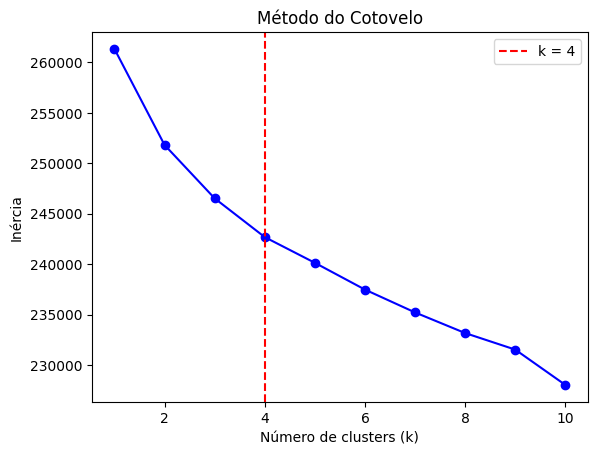

/tmp/ipykernel_25334/43589684.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Encoding['Cluster'] = kmeans.fit_predict(X_final)


In [72]:
# 2. Separar colunas categóricas e numéricas
cat_cols = ['STATUS_-', 'STATUS_APROVADO', 'STATUS_CONSULTA',
    'STATUS_NEGADO', 'STATUS_PENDENTE', 'Soil_Type_Clay', 'Soil_Type_Loam', 'Soil_Type_Peaty', 'Soil_Type_Sandy', 'Soil_Type_Silt', 'Crop_Cotton', 'Crop_Maize', 'Crop_Rice', 'Crop_Soybean', 'Crop_Wheat', 'Weather_Condition_Rainy', 'Weather_Condition_Sunny', 'Fertilizer_Used', 'Irrigation_Used']
num_cols = ['Rainfall_mm', 'Temperature_Celsius', 'Days_to_Harvest', 'RFR_QTD', 'RFR_VLT', 'CSF_VLT', 'TPN_QTD', 'TPN_VLT', 'RJF_QTD',
    'RJF_VLT', 'LC_VLT', 'RI_QTD_TOT', 'RI_VALOR', 'PN_VALOR',
    'RR_INST_QTD', 'RR_OP_QTD', 'CC_A_PAGAR', 'CC_DIV_NAO_PAGAS',
    'CC_PREJUIZO', 'CC_LIMITE', 'PC_QTD_TOT', 'IDADE_RELACIONAMENTO_DIAS',
    'CRC_NUMERICA']

# 3. One-hot encode das variáveis categóricas
encoder = OneHotEncoder(drop='first', sparse_output=False)
X_cat = encoder.fit_transform(X[cat_cols])

# 4. Normalizar variáveis numéricas
scaler = StandardScaler()
X_num = scaler.fit_transform(X[num_cols])

# 5. Concatenar tudo
X_final = np.concatenate([X_cat, X_num], axis=1)

# 6. Encontrar o melhor valor de k usando a regra do cotovelo
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_final)
    inertias.append(kmeans.inertia_)

# 7. Encontrar o "cotovelo"
kl = KneeLocator(k_range, inertias, curve="convex", direction="decreasing")
best_k = kl.elbow

print(f"Melhor número de clusters estimado (k): {best_k}")

# 8. Plotar o gráfico do cotovelo (opcional)
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')
plt.axvline(best_k, color='r', linestyle='--', label=f'k = {best_k}')
plt.legend()
plt.show()

# 9. Rodar o KMeans com o melhor k
kmeans = KMeans(n_clusters=best_k, random_state=42)
df_Encoding['Cluster'] = kmeans.fit_predict(X_final)


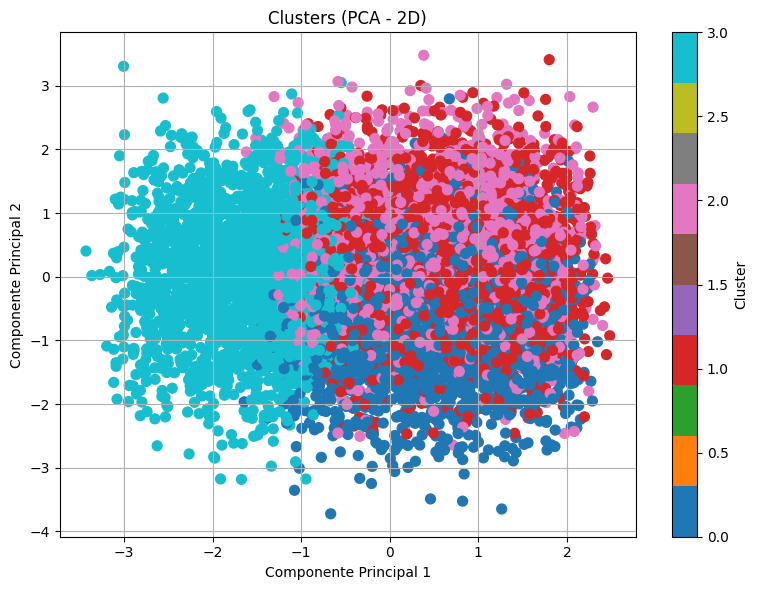

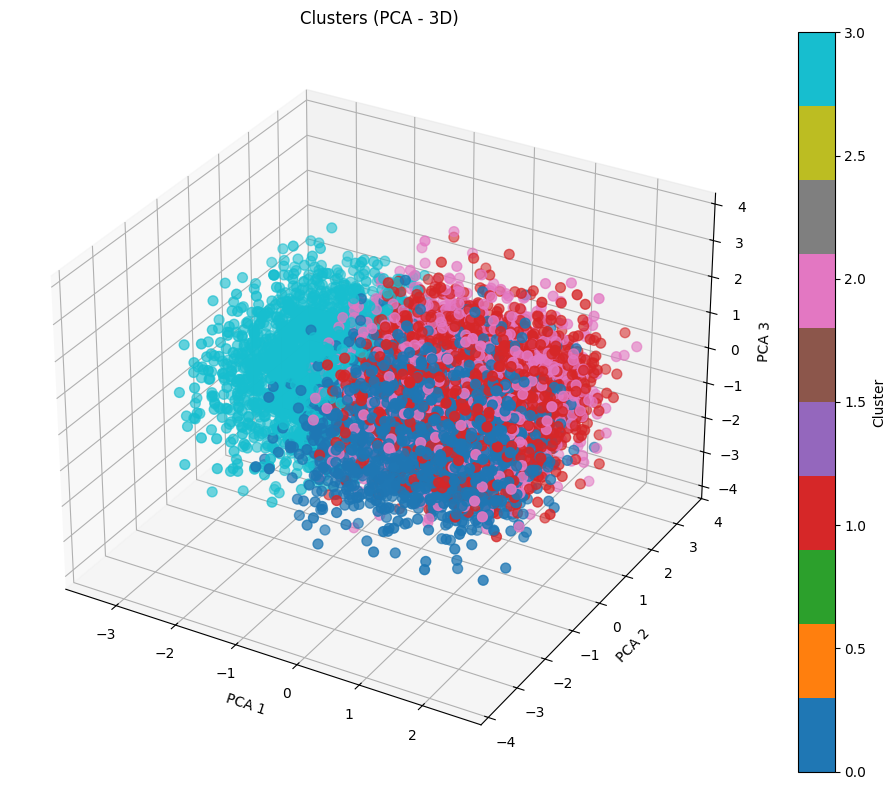

In [73]:
# Aplicar PCA para redução de dimensionalidade
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_final)

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_final)

# Adicionando colunas PCA ao DataFrame (opcional)
df_Encoding['PCA1'] = X_pca_2d[:, 0]
df_Encoding['PCA2'] = X_pca_2d[:, 1]

# Plot 2D
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=df_Encoding['Cluster'], cmap='tab10', s=50)
plt.title('Clusters (PCA - 2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter_3d = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                        c=df_Encoding['Cluster'], cmap='tab10', s=50)
ax.set_title('Clusters (PCA - 3D)')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
fig.colorbar(scatter_3d, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()


In [74]:
# --- 1. SELEÇÃO DE FEATURES E DEFINIÇÃO DOS PESOS AHP SIMULADOS ---

# 1.1 Lista de todas as colunas do seu dataset que serão usadas no Score.
colunas_score = [
    'RFR_QTD', 'RFR_VLT', 'CSF_VLT', 'TPN_QTD', 'TPN_VLT', 'RJF_QTD',
    'RJF_VLT', 'LC_VLT', 'RI_QTD_TOT', 'RI_VALOR', 'PN_VALOR',
    'RR_INST_QTD', 'RR_OP_QTD', 'CC_A_PAGAR', 'CC_DIV_NAO_PAGAS',
    'CC_PREJUIZO', 'CC_LIMITE', 'PC_QTD_TOT', 'IDADE_RELACIONAMENTO_DIAS',
    'CRC_NUMERICA', 'STATUS_-', 'STATUS_APROVADO', 'STATUS_CONSULTA',
    'STATUS_NEGADO', 'STATUS_PENDENTE',
    # Colunas Geológicas/Cultivo (assumindo que já estão numéricas/codificadas)
    'Soil_Type_Clay', 'Soil_Type_Loam', 'Soil_Type_Peaty', 'Soil_Type_Sandy',
    'Soil_Type_Silt', 'Crop_Cotton', 'Crop_Maize', 'Crop_Rice', 'Crop_Soybean',
    'Crop_Wheat', 'Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used',
    'Irrigation_Used', 'Days_to_Harvest', 'Weather_Condition_Rainy',
    'Weather_Condition_Sunny'
]

# 1.2 Definição dos Pesos AHP (Fase 2).
# ESTES SÃO PESOS DE EXEMPLO! Você DEVE substituí-los pelos pesos reais
# calculados na sua matriz de comparação AHP.
# NOTA: A soma total dos pesos deve ser 1.0.

pesos_ahp = {
    # Risco Financeiro Principal (Maior Impacto)
    'CRC_NUMERICA': 0.15,
    'RI_VALOR': 0.10,

    # Risco Financeiro Secundário
    'RFR_VLT': 0.05, 'CSF_VLT': 0.05, 'TPN_VLT': 0.03, 'RJF_VLT': 0.03,
    'LC_VLT': 0.02, 'PN_VALOR': 0.02,

    # Histórico e Relacionamento
    'RR_INST_QTD': 0.04, 'RR_OP_QTD': 0.02, 'IDADE_RELACIONAMENTO_DIAS': 0.03,

    # Dívidas e Limites
    'CC_A_PAGAR': 0.05, 'CC_DIV_NAO_PAGAS': 0.05, 'CC_PREJUIZO': 0.05,
    'CC_LIMITE': 0.03,

    # Quantitativos Simples (Menor Impacto)
    'RFR_QTD': 0.01, 'TPN_QTD': 0.01, 'RJF_QTD': 0.01, 'RI_QTD_TOT': 0.01,
    'PC_QTD_TOT': 0.01,

    # Status (Colunas Dummies)
    'STATUS_APROVADO': 0.01, 'STATUS_NEGADO': 0.03, 'STATUS_CONSULTA': 0.01,
    'STATUS_-': 0.005, 'STATUS_PENDENTE': 0.005,

    # Risco de Cultivo/Geológico (Pesos de Exemplo)
    'Rainfall_mm': 0.05, 'Temperature_Celsius': 0.02, 'Days_to_Harvest': 0.02,
    'Soil_Type_Clay': 0.01, 'Soil_Type_Loam': 0.01, 'Soil_Type_Peaty': 0.01,
    'Soil_Type_Sandy': 0.01, 'Soil_Type_Silt': 0.01,
    'Crop_Cotton': 0.005, 'Crop_Maize': 0.005, 'Crop_Rice': 0.005,
    'Crop_Soybean': 0.005, 'Crop_Wheat': 0.005,
    'Fertilizer_Used': 0.01, 'Irrigation_Used': 0.01,
    'Weather_Condition_Rainy': 0.01, 'Weather_Condition_Sunny': 0.01
}

# 1.3 Converte os pesos para uma série de Pandas para garantir a ordenação correta
pesos_serie = pd.Series(pesos_ahp)

# 2.0 Filtra o DataFrame para usar apenas as colunas com pesos definidos
# Isso também serve como um check para garantir que todas as colunas existem no df_Encoding
X_score = df_Encoding[colunas_score]

# 2.1 Reordenar os pesos para coincidir com a ordem das colunas no DataFrame de treino
pesos_ordenados = pesos_serie.reindex(X_score.columns)

# --- 3. CÁLCULO DO SCORE FINAL (Fórmula AHP) ---

# 3.1 Aplica a fórmula de Soma Ponderada (S_j = SUM(V_i,j * W_i))
# A multiplicação matricial (.dot) calcula o score bruto para cada linha.
df_Encoding['SCORE_AHP_BRUTO'] = X_score.dot(pesos_ordenados)

print("\nCálculo do Score AHP Bruto Concluído.")
print(f"Soma dos pesos usados: {round(pesos_ordenados.sum(), 2)}")


# --- 4. NORMALIZAÇÃO FINAL PARA ESCALA 0-100 (Melhor Interpretação) ---

# 4.1 Calcula os valores mínimo e máximo do score bruto
min_score = df_Encoding['SCORE_AHP_BRUTO'].min()
max_score = df_Encoding['SCORE_AHP_BRUTO'].max()

# 4.2 Normaliza para a escala 0 a 100
# Um score de 100 representa o perfil de 'confiabilidade' mais próximo do ideal ponderado.
df_Encoding['SCORE_FINAL_CONFIABILIDADE'] = (
    (df_Encoding['SCORE_AHP_BRUTO'] - min_score) / (max_score - min_score) * 100
)

print("\n" + "="*70)
print("Score de Confiabilidade Finalizado!")
print("Coluna 'SCORE_FINAL_CONFIABILIDADE' adicionada ao seu DataFrame.")
print("="*70)

# Verificação
print("Estatísticas do Score Final (Escala 0-100):")
print(df_Encoding['SCORE_FINAL_CONFIABILIDADE'].describe())


Cálculo do Score AHP Bruto Concluído.
Soma dos pesos usados: 1.04

Score de Confiabilidade Finalizado!
Coluna 'SCORE_FINAL_CONFIABILIDADE' adicionada ao seu DataFrame.
Estatísticas do Score Final (Escala 0-100):
count     10000.000000
unique    10000.000000
top          70.596618
freq          1.000000
Name: SCORE_FINAL_CONFIABILIDADE, dtype: float64


In [75]:
df_Encoding.head(5)

,RFR_QTD,RFR_VLT,CSF_VLT,TPN_QTD,TPN_VLT,RJF_QTD,RJF_VLT,LC_VLT,RI_QTD_TOT,RI_VALOR,...,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Weather_Condition_Rainy,Weather_Condition_Sunny,Cluster,PCA1,PCA2,SCORE_AHP_BRUTO,SCORE_FINAL_CONFIABILIDADE
0,0.066667,0.568100,0.492451,0.400000,0.419333,0.8,0.411060,0.060458,0.421053,0.849497,...,False,True,0.696629,False,False,2,1.035613,-0.136351,0.560879,70.596618
1,0.200000,0.039627,0.492451,0.533333,0.104188,0.8,0.412337,0.072266,0.421053,0.575192,...,True,True,0.898876,True,False,3,-0.713432,-0.240108,0.471511,55.218766
2,0.700000,0.305616,0.492451,0.933333,0.078761,0.5,0.275363,0.164609,0.578947,0.534820,...,False,False,0.516854,False,True,1,0.604980,0.759264,0.355068,35.182004
3,0.466667,0.059941,0.094614,0.066667,0.336630,0.5,0.966195,0.486843,0.000000,0.907969,...,False,True,0.966292,True,False,3,-1.925870,0.779128,0.487997,58.055548
4,0.633333,0.340664,0.449212,0.333333,0.712299,1.0,0.373469,0.130171,0.684211,0.027228,...,True,True,0.561798,False,False,3,-2.403615,0.394752,0.339271,32.463841


In [76]:
'''
Plotar gráfico

Verificar dados dupolicados.
Apagar os dados duplicados.
'''

'\nPlotar gráfico\n\nVerificar dados dupolicados.\nApagar os dados duplicados.\n'

In [77]:
def grup(data):
  if data <= 25:
    return 1
  elif (data > 25 and data <= 50):
    return 2
  elif (data > 50 and data <= 75):
    return 3
  elif (data > 75 and data <= 100):
    return 4
  else:
      return None

In [78]:
df_Encoding['Score'] = df_Encoding['SCORE_FINAL_CONFIABILIDADE'].apply(grup)
df_Encoding.head(3)

,RFR_QTD,RFR_VLT,CSF_VLT,TPN_QTD,TPN_VLT,RJF_QTD,RJF_VLT,LC_VLT,RI_QTD_TOT,RI_VALOR,...,Irrigation_Used,Days_to_Harvest,Weather_Condition_Rainy,Weather_Condition_Sunny,Cluster,PCA1,PCA2,SCORE_AHP_BRUTO,SCORE_FINAL_CONFIABILIDADE,Score
0,0.066667,0.568100,0.492451,0.400000,0.419333,0.8,0.411060,0.060458,0.421053,0.849497,...,True,0.696629,False,False,2,1.035613,-0.136351,0.560879,70.596618,3
1,0.200000,0.039627,0.492451,0.533333,0.104188,0.8,0.412337,0.072266,0.421053,0.575192,...,True,0.898876,True,False,3,-0.713432,-0.240108,0.471511,55.218766,3
2,0.700000,0.305616,0.492451,0.933333,0.078761,0.5,0.275363,0.164609,0.578947,0.534820,...,False,0.516854,False,True,1,0.604980,0.759264,0.355068,35.182004,2


In [79]:
df_Encoding.Score.value_counts()

Score
2    4576
3    4459
1     520
4     445
Name: count, dtype: int64

/tmp/ipykernel_25334/2515629879.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


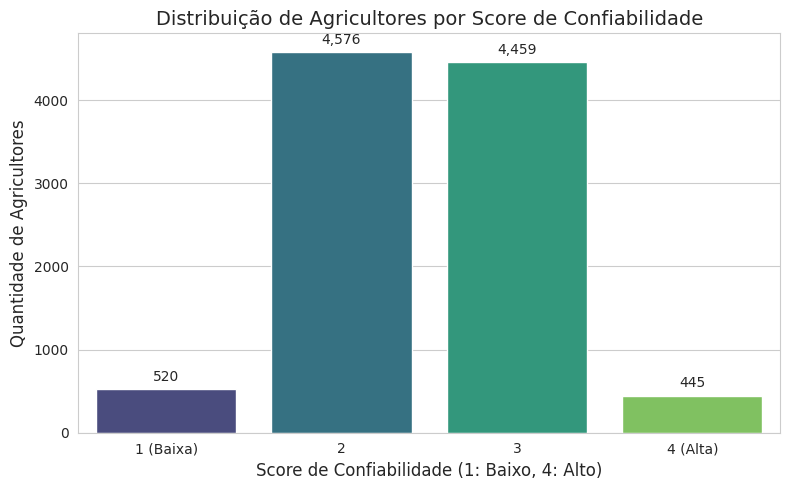

In [80]:
# 1. Obter os dados de contagem (o resultado do seu value_counts())
contagem_scores = df_Encoding['Score'].value_counts().sort_index()

# 2. Configurações para o gráfico
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

# 3. Criar o gráfico de barras
ax = sns.barplot(
    x=contagem_scores.index,  # Nomes das barras (1, 2, 3, 4)
    y=contagem_scores.values, # Altura das barras (Contagem de Agricultores)
    palette="viridis"
)

# 4. Adicionar rótulos de dados (o número exato de agricultores em cima de cada barra)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10)

# 5. Adicionar títulos e rótulos
plt.title('Distribuição de Agricultores por Score de Confiabilidade', fontsize=14)
plt.xlabel('Score de Confiabilidade (1: Baixo, 4: Alto)', fontsize=12)
plt.ylabel('Quantidade de Agricultores', fontsize=12)
plt.xticks(ticks=[0, 1, 2, 3], labels=['1 (Baixa)', '2', '3', '4 (Alta)'])
plt.tight_layout() # Ajusta o layout para evitar cortes
plt.show()

In [81]:
'''
Criação do Score para os compradores
'''

'\nCriação do Score para os compradores\n'

In [82]:
'''
Sequência de passos a serem executados:
Importação dos dados

Anáçise Exploratória dos dados

Limpeza dos dados

Engenharia de atributos

Implementação do método AHP

Criação do Score
'''

'\nSequência de passos a serem executados:\nImportação dos dados\n\nAnáçise Exploratória dos dados\n\nLimpeza dos dados\n\nEngenharia de atributos\n\nImplementação do método AHP\n\nCriação do Score\n'

In [83]:
comp = pd.read_csv('data/Loan_default.csv')
comp.head(1)

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0


In [84]:
comp.shape

(255347, 18)

In [85]:
comp.Default.unique()

array([0, 1])

In [86]:
import pandas as pd
# Lista das colunas a serem usadas como critérios/subcritérios no AHP
# Excluindo 'LoanID' (Identificador) e 'Default' (Target)
colunas_score = [
    'Age',
    'Income',
    'LoanAmount',
    'CreditScore',
    'MonthsEmployed',
    'NumCreditLines',
    'InterestRate',
    'LoanTerm',
    'DTIRatio',
    'Education',
    'EmploymentType',
    'MaritalStatus',
    'HasMortgage',
    'HasDependents',
    'LoanPurpose',
    'HasCoSigner'
]

# Cria um novo DataFrame apenas com as colunas selecionadas
df_score = comp[colunas_score]

df_score.head()


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No


In [87]:
df_score.Education.unique()

array(["Bachelor's", "Master's", 'High School', 'PhD'], dtype=object)

In [88]:
education_map = {
    'High School': 1,
    "Bachelor's": 2,
    "Master's": 3,
    'PhD': 4
}

df_score['Education_Encoded'] = df_score['Education'].map(education_map)
df_score.drop(columns=['Education'], inplace=True)
df_score.head(5)

/tmp/ipykernel_25334/2475685994.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_score['Education_Encoded'] = df_score['Education'].map(education_map)
/tmp/ipykernel_25334/2475685994.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_score.drop(columns=['Education'], inplace=True)


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Education_Encoded
0,56,85994,50587,520,80,4,15.23,36,0.44,Full-time,Divorced,Yes,Yes,Other,Yes,2
1,69,50432,124440,458,15,1,4.81,60,0.68,Full-time,Married,No,No,Other,Yes,3
2,46,84208,129188,451,26,3,21.17,24,0.31,Unemployed,Divorced,Yes,Yes,Auto,No,3
3,32,31713,44799,743,0,3,7.07,24,0.23,Full-time,Married,No,No,Business,No,1
4,60,20437,9139,633,8,4,6.51,48,0.73,Unemployed,Divorced,No,Yes,Auto,No,2


In [89]:
df_encoded = pd.get_dummies(df_score, columns=['EmploymentType'], prefix='Employment')
df_encoded = pd.get_dummies(df_encoded, columns=['MaritalStatus'], prefix='MaritalStatus')
df_encoded = pd.get_dummies(df_encoded, columns=['LoanPurpose'], prefix='LoanPurpose')

In [90]:
colunas_binarias = ['HasMortgage', 'HasCoSigner', 'HasDependents']

binary_map = {
    'Yes': 1,
    'No': 0
}

for col in colunas_binarias:
    df_encoded[col] = df_encoded[col].replace(binary_map)

for col in colunas_binarias:
    df_encoded[col] = df_encoded[col].astype(int)


/tmp/ipykernel_25334/74828477.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_encoded[col] = df_encoded[col].replace(binary_map)


In [91]:
colunas_para_normalizar = [
    'Age',
    'Income',
    'LoanAmount',
    'CreditScore',
    'MonthsEmployed',
    'NumCreditLines',
    'InterestRate',
    'LoanTerm',
    'DTIRatio'
]

# 2. Inicializar o MinMaxScaler
scaler = MinMaxScaler()
df_encoded[colunas_para_normalizar] = scaler.fit_transform(df_encoded[colunas_para_normalizar])

In [92]:
df_encoded.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,HasMortgage,...,Employment_Self-employed,Employment_Unemployed,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Auto,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,0.745098,0.525885,0.186070,0.400729,0.672269,1.000000,0.575217,0.50,0.4250,1,...,False,False,True,False,False,False,False,False,False,True
1,1.000000,0.262461,0.487512,0.287796,0.126050,0.000000,0.122174,1.00,0.7250,0,...,False,False,False,True,False,False,False,False,False,True
2,0.549020,0.512656,0.506892,0.275046,0.218487,0.666667,0.833478,0.25,0.2625,1,...,False,True,True,False,False,True,False,False,False,False
3,0.274510,0.123801,0.162446,0.806922,0.000000,0.666667,0.220435,0.25,0.1625,0,...,False,False,False,True,False,False,True,False,False,False
4,0.823529,0.040274,0.016894,0.606557,0.067227,1.000000,0.196087,0.75,0.7875,0,...,False,True,True,False,False,True,False,False,False,False


In [93]:
df_score.HasDependents.unique()

array(['Yes', 'No'], dtype=object)

In [94]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Age                       255347 non-null  float64
 1   Income                    255347 non-null  float64
 2   LoanAmount                255347 non-null  float64
 3   CreditScore               255347 non-null  float64
 4   MonthsEmployed            255347 non-null  float64
 5   NumCreditLines            255347 non-null  float64
 6   InterestRate              255347 non-null  float64
 7   LoanTerm                  255347 non-null  float64
 8   DTIRatio                  255347 non-null  float64
 9   HasMortgage               255347 non-null  int64  
 10  HasDependents             255347 non-null  int64  
 11  HasCoSigner               255347 non-null  int64  
 12  Education_Encoded         255347 non-null  int64  
 13  Employment_Full-time      255347 non-null  b

In [95]:
'''
Criação da Estrutura para a criação do Score do comprador
'''

'\nCriação da Estrutura para a criação do Score do comprador\n'

In [96]:
# --- 1. DEFINIÇÃO DA HIERARQUIA E SIMULAÇÃO DOS PESOS AHP ---

# Nível 2: Critérios Principais e seus Pesos Globais (Simulados)
# ESTES PESOS DEVEM SER CALCULADOS MANUALMENTE (OU COM BIBLIOTECA AHP)
# A PARTIR DAS MATRIZES DE COMPARAÇÃO PAR A PAR REAIS.
PESOS_CRITERIOS = {
    'Caráter': 0.35,
    'Capacidade': 0.30,
    'Condição': 0.20,
    'Capital': 0.10,
    'Colateral_Outros': 0.05
}

# Nível 3: Mapeamento de Subcritérios (Suas Variáveis) para os Critérios Principais
# E seus Pesos Locais (Simulados). A soma dos pesos locais deve ser 1.0 para cada critério.
PESOS_SUB_CRITERIOS = {
    # ------------------ Caráter (0.35) ------------------
    'Caráter': {
        'CreditScore': 0.60,       # Peso alto: A pontuação de crédito é o pilar do Caráter
        'Education_Encoded': 0.25, # Educação, bom indicativo de estabilidade
        'NumCreditLines': 0.15     # Poucas linhas de crédito (menos risco)
    },
    # ------------------ Capacidade (0.30) ------------------
    'Capacidade': {
        'Income': 0.50,            # Renda é o principal indicador de capacidade de pagamento
        'MonthsEmployed': 0.30,    # Estabilidade no emprego
        'Employment_Full-time': 0.10,
        'Employment_Part-time': 0.03,
        'Employment_Self-employed': 0.05,
        'Employment_Unemployed': 0.02 # Peso baixo: Risco alto
    },
    # ------------------ Condição (0.20) ------------------
    'Condição': {
        'DTIRatio': 0.45,          # Razão Dívida/Renda (muito importante)
        'InterestRate': 0.25,      # Taxa de juros do empréstimo (menor é melhor)
        'LoanTerm': 0.10,          # Prazo do empréstimo (em geral, menor é menos arriscado)
        'LoanPurpose_Home': 0.08,  # Financiamento de casa (mais seguro)
        'LoanPurpose_Business': 0.05,
        'LoanPurpose_Education': 0.03,
        'LoanPurpose_Auto': 0.03,
        'LoanPurpose_Other': 0.01  # Menos seguro/justificado
    },
    # ------------------ Capital (0.10) ------------------
    'Capital': {
        'LoanAmount': 1.00         # Única variável nesta categoria
    },
    # ------------------ Colateral_Outros (0.05) ------------------
    'Colateral_Outros': {
        'HasMortgage': 0.50,       # Hipoteca como garantia/estabilidade
        'HasCoSigner': 0.20,       # Co-signatário (mitiga risco)
        'Age': 0.15,               # Idade (mais velho = mais estável, em geral)
        'HasDependents': 0.05,     # Menos dependentes é melhor (simulado)
        'MaritalStatus_Married': 0.05, # Casado (simulado como mais estável)
        'MaritalStatus_Single': 0.03,
        'MaritalStatus_Divorced': 0.02
    }
}

# --- 2. CÁLCULO DOS PESOS GLOBAIS FINAIS ---

pesos_globais_finais = {}
for criterio_principal, peso_principal in PESOS_CRITERIOS.items():
    for sub_criterio, peso_local in PESOS_SUB_CRITERIOS[criterio_principal].items():
        # Peso Global = Peso Principal * Peso Local
        pesos_globais_finais[sub_criterio] = peso_principal * peso_local

# Conversão para um DataFrame para fácil aplicação
df_pesos = pd.Series(pesos_globais_finais).to_frame(name='PesoGlobal')

# Verificação (opcional): A soma deve ser próxima de 1.0
soma_pesos = df_pesos['PesoGlobal'].sum()
print(f"Soma dos Pesos Globais (deve ser ~1.0): {soma_pesos:.4f}\n")
print("Pesos Globais Finais por Variável:")
print(df_pesos)


# --- 3. PRÉ-PROCESSAMENTO: REVERSÃO DE VARIAÇÃO (PARA O AHP) ---

# No AHP, um valor mais alto sempre deve ser "melhor".
# Algumas variáveis (InterestRate, DTIRatio, LoanTerm, Unemployed) são 'bad-is-good'
# (quanto maior, pior para o score). Precisamos inverter o valor dessas variáveis para
# que elas se encaixem na lógica AHP (quanto maior o valor, maior a contribuição para o Score).

# Variáveis onde o valor maior é PIOR para o risco/score (bad-is-good)
variaveis_inversas = [
    'InterestRate',
    'DTIRatio',
    'LoanTerm',
    'Employment_Unemployed',
    'MaritalStatus_Divorced'
]

df_calculo = df_encoded.copy()

for col in variaveis_inversas:
    # Inversão: 1 - Valor_Normalizado
    # Se o DTI for 0.9 (Alto Risco), ele vira 0.1 (Baixa Contribuição para o Score)
    df_calculo[col] = 1 - df_calculo[col]

# Tratamento de colunas bool, convertendo True/False para 1/0
for col in df_calculo.select_dtypes(include=['bool']).columns:
    df_calculo[col] = df_calculo[col].astype(int)

# --- 4. CÁLCULO DO SCORE AHP (0 a 100) ---

# Lista das variáveis de score que devem estar no DataFrame
variaveis_score = list(df_pesos.index)

# Apenas as colunas necessárias e na ordem correta
df_score_vars = df_calculo[variaveis_score]

# Multiplicação Matricial: (Valores dos Mutuários) * (Pesos Globais)
# Score AHP (0 a 1) = Soma Ponderada dos Valores Normalizados/Invertidos
score_ahp_0_a_1 = np.dot(df_score_vars, df_pesos['PesoGlobal'])

# Escalonamento para a faixa de 0 a 100
score_final_0_a_100 = score_ahp_0_a_1 * 100

# Adicionar a coluna de score final ao DataFrame
df_encoded['AHP_Score_100'] = score_final_0_a_100



Soma dos Pesos Globais (deve ser ~1.0): 1.0000

Pesos Globais Finais por Variável:
                          PesoGlobal
CreditScore                   0.2100
Education_Encoded             0.0875
NumCreditLines                0.0525
Income                        0.1500
MonthsEmployed                0.0900
Employment_Full-time          0.0300
Employment_Part-time          0.0090
Employment_Self-employed      0.0150
Employment_Unemployed         0.0060
DTIRatio                      0.0900
InterestRate                  0.0500
LoanTerm                      0.0200
LoanPurpose_Home              0.0160
LoanPurpose_Business          0.0100
LoanPurpose_Education         0.0060
LoanPurpose_Auto              0.0060
LoanPurpose_Other             0.0020
LoanAmount                    0.1000
HasMortgage                   0.0250
HasCoSigner                   0.0100
Age                           0.0075
HasDependents                 0.0025
MaritalStatus_Married         0.0025
MaritalStatus_Single         

In [97]:
df_encoded.head(3)

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,HasMortgage,...,Employment_Unemployed,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Auto,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,AHP_Score_100
0,0.745098,0.525885,0.186070,0.400729,0.672269,1.000000,0.575217,0.50,0.4250,1,...,False,True,False,False,False,False,False,False,True,63.372439
1,1.000000,0.262461,0.487512,0.287796,0.126050,0.000000,0.122174,1.00,0.7250,0,...,False,False,True,False,False,False,False,False,True,55.004340
2,0.549020,0.512656,0.506892,0.275046,0.218487,0.666667,0.833478,0.25,0.2625,1,...,True,True,False,False,True,False,False,False,False,62.982970


In [98]:
def grup(data):
  if data <= 25:
    return 1
  elif (data > 25 and data <= 50):
    return 2
  elif (data > 50 and data <= 75):
    return 3
  elif (data > 75 and data <= 100):
    return 4
  else:
      return None

In [99]:
df_encoded['Score'] = df_encoded['AHP_Score_100'].apply(grup)
df_encoded.head(2)

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,HasMortgage,...,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Auto,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,AHP_Score_100,Score
0,0.745098,0.525885,0.186070,0.400729,0.672269,1.0,0.575217,0.5,0.425,1,...,True,False,False,False,False,False,False,True,63.372439,3.0
1,1.000000,0.262461,0.487512,0.287796,0.126050,0.0,0.122174,1.0,0.725,0,...,False,True,False,False,False,False,False,True,55.004340,3.0


/tmp/ipykernel_25334/3292796301.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


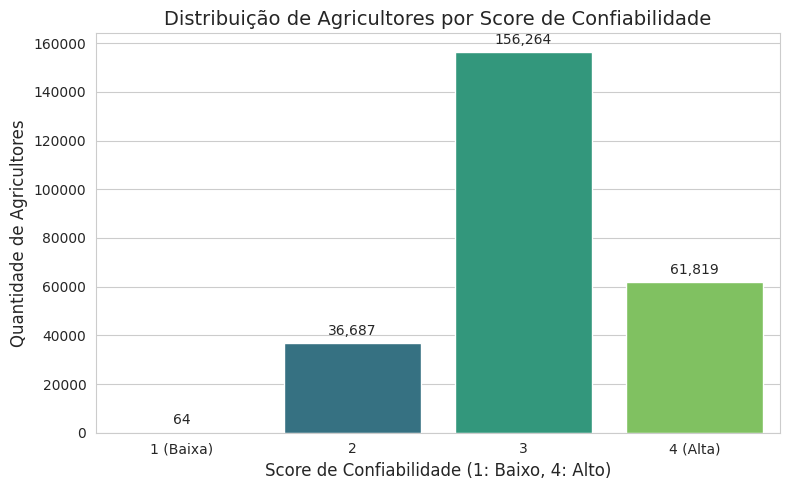

In [100]:
# 1. Obter os dados de contagem (o resultado do seu value_counts())
contagem_scores = df_encoded['Score'].value_counts().sort_index()

# 2. Configurações para o gráfico
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

# 3. Criar o gráfico de barras
ax = sns.barplot(
    x=contagem_scores.index,  # Nomes das barras (1, 2, 3, 4)
    y=contagem_scores.values, # Altura das barras (Contagem de Agricultores)
    palette="viridis"
)

# 4. Adicionar rótulos de dados (o número exato de agricultores em cima de cada barra)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10)

# 5. Adicionar títulos e rótulos
plt.title('Distribuição de Agricultores por Score de Confiabilidade', fontsize=14)
plt.xlabel('Score de Confiabilidade (1: Baixo, 4: Alto)', fontsize=12)
plt.ylabel('Quantidade de Agricultores', fontsize=12)
plt.xticks(ticks=[0, 1, 2, 3], labels=['1 (Baixa)', '2', '3', '4 (Alta)'])
plt.tight_layout() # Ajusta o layout para evitar cortes
plt.show()

/tmp/ipykernel_25334/1099024419.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=score_counts.index, y=score_counts.values, palette="viridis")


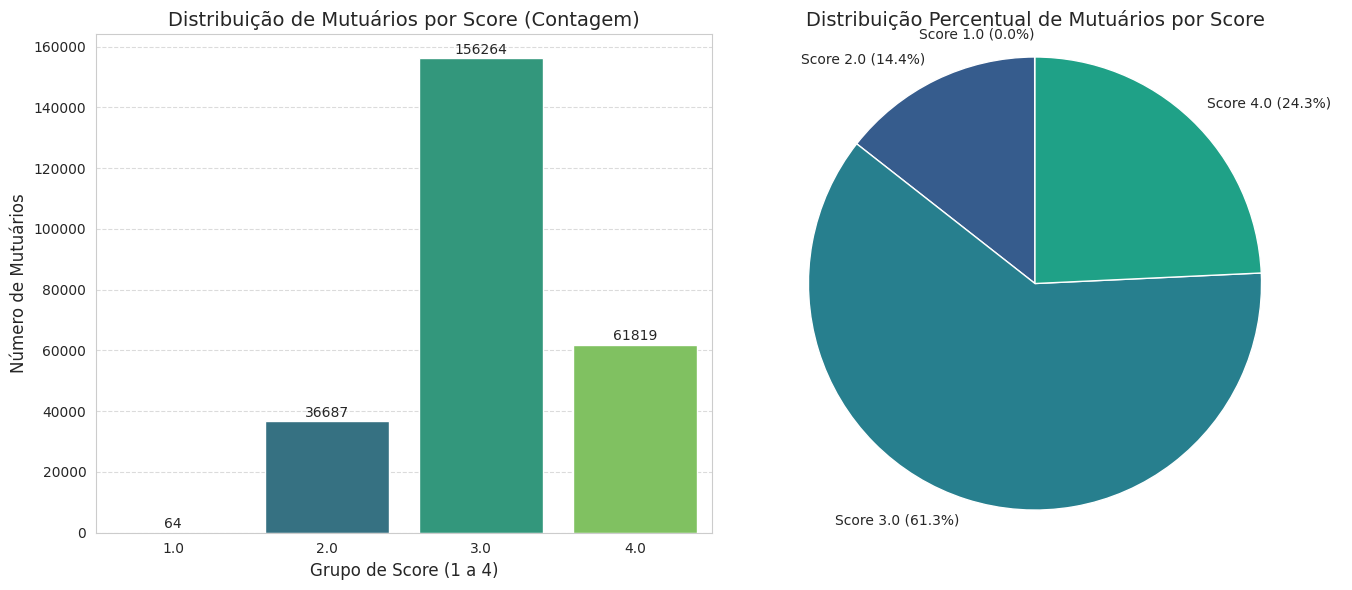

/tmp/ipykernel_25334/1099024419.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Score', y='AHP_Score_100', data=df_encoded, palette="magma")


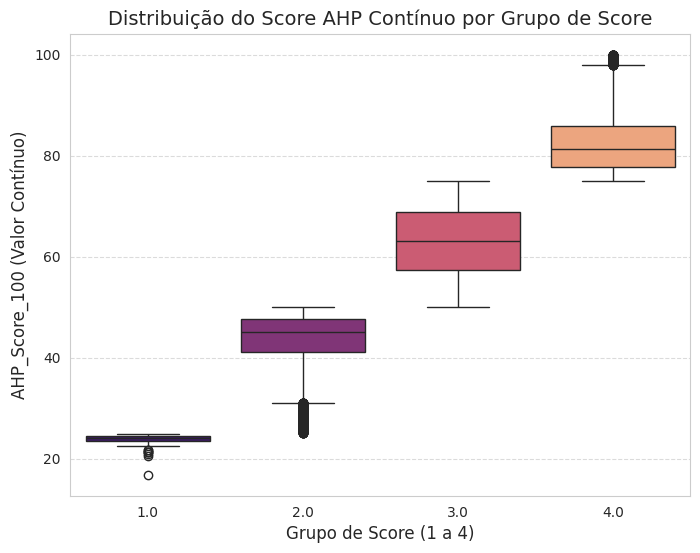

In [101]:
# --- 1. GRÁFICO DE BARRAS E GRÁFICO DE PIZZA (DISTRIBUIÇÃO POR SCORE) ---

# Tabela de contagem e percentual
score_counts = df_encoded['Score'].value_counts().sort_index()
score_percentages = df_encoded['Score'].value_counts(normalize=True).sort_index() * 100

# Configuração da figura com 2 subplots
plt.figure(figsize=(14, 6))

# --- GRÁFICO DE BARRAS (Contagem) ---
plt.subplot(1, 2, 1)
sns.barplot(x=score_counts.index, y=score_counts.values, palette="viridis")
plt.title('Distribuição de Mutuários por Score (Contagem)', fontsize=14)
plt.xlabel('Grupo de Score (1 a 4)', fontsize=12)
plt.ylabel('Número de Mutuários', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adiciona os valores nas barras
for i, count in enumerate(score_counts.values):
    plt.text(i, count + 500, f'{count}', ha='center', va='bottom', fontsize=10)


# --- GRÁFICO DE PIZZA (Percentual) ---
plt.subplot(1, 2, 2)
# Rótulos com o percentual formatado
labels = [f'Score {i} ({p:.1f}%)' for i, p in score_percentages.items()]
plt.pie(score_counts.values, labels=labels, autopct='', startangle=90, colors=sns.color_palette("viridis"))
plt.title('Distribuição Percentual de Mutuários por Score', fontsize=14)
plt.axis('equal') # Garante que o gráfico de pizza seja circular

plt.tight_layout()
plt.show()


# --- 2. GRÁFICO ADICIONAL: BOXPLOT DO SCORE AHP POR GRUPO ---

plt.figure(figsize=(8, 6))
# É bom garantir que o 'Score' seja tratado como categoria ordenada
df_encoded['Score'] = df_encoded['Score'].astype('category')

sns.boxplot(x='Score', y='AHP_Score_100', data=df_encoded, palette="magma")
plt.title('Distribuição do Score AHP Contínuo por Grupo de Score', fontsize=14)
plt.xlabel('Grupo de Score (1 a 4)', fontsize=12)
plt.ylabel('AHP_Score_100 (Valor Contínuo)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()